# Universidad Politécnica Salesiana - Carrera de Computación
## Proyecto Integrador de Computación Paralela
# Procesamiento Distribuido y Reconstrucción de Trayectorias Sintéticas en Registros Nacionales de Egresos Hospitalarios

**Integrantes:** Gerardo Rocafuerte, Jull Licoa, Marcos Echeverría  
**Materia:** Computación Paralela  
**Docente:** Joffre León  
**Periodo:** 68 - julio 2026


## 1. Preparación del entorno de trabajo

En esta sección se instalan las dependencias necesarias, se conecta Google Drive, se comprueban los recursos disponibles y se crean las carpetas del proyecto.


In [1]:
!pip install -q pandas numpy matplotlib psutil memory_profiler requests pyarrow fastparquet openpyxl "dask[distributed]"

In [20]:
!pip install -q "dask[distributed]" pandas numpy matplotlib psutil pyarrow bokeh graphviz python-docx reportlab
!apt-get update -qq
!apt-get install -y -qq graphviz


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import sys
import pandas as pd
import numpy as np
import dask
import dask.dataframe as dd
import psutil
import pyarrow

from dask.distributed import Client, LocalCluster

print("✅ Entorno configurado correctamente")
print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("Dask:", dask.__version__)
print("PyArrow:", pyarrow.__version__)
print("CPU lógicas disponibles:", os.cpu_count())
print(
    "Memoria RAM total:",
    round(psutil.virtual_memory().total / (1024**3), 2),
    "GB"
)

✅ Entorno configurado correctamente
Python: 3.12.13
Pandas: 2.2.2
Dask: 2026.7.0
PyArrow: 18.1.0
CPU lógicas disponibles: 2
Memoria RAM total: 12.67 GB


In [4]:
from pathlib import Path

PROYECTO = Path(
    "/content/drive/MyDrive/Proyecto_INEC_Paralela"
)

RAW = PROYECTO / "datos_raw"
EXTRAIDOS = PROYECTO / "datos_extraidos"
PARQUET = PROYECTO / "datos_parquet"
RESULTADOS = PROYECTO / "resultados"
FIGURAS = RESULTADOS / "figuras"
REPORTES_DASK = RESULTADOS / "reportes_dask"

CARPETAS = [
    RAW,
    EXTRAIDOS,
    PARQUET,
    RESULTADOS,
    FIGURAS,
    REPORTES_DASK,
]

for carpeta in CARPETAS:
    carpeta.mkdir(parents=True, exist_ok=True)

print("✅ Carpetas creadas correctamente")
print("Carpeta principal:", PROYECTO)

for carpeta in CARPETAS:
    print(" -", carpeta)

✅ Carpetas creadas correctamente
Carpeta principal: /content/drive/MyDrive/Proyecto_INEC_Paralela
 - /content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw
 - /content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos
 - /content/drive/MyDrive/Proyecto_INEC_Paralela/datos_parquet
 - /content/drive/MyDrive/Proyecto_INEC_Paralela/resultados
 - /content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/figuras
 - /content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/reportes_dask


## 2. Localización y descarga de los microdatos del INEC

Se identifican y descargan las bases oficiales de egresos hospitalarios correspondientes a los años 2020-2024.

In [27]:
!pip install -q beautifulsoup4

import requests
import pandas as pd

from bs4 import BeautifulSoup
from urllib.parse import urljoin

PAGINAS_INEC = {
    2020: "https://www.ecuadorencifras.gob.ec/camas-y-egresos-hospitalarios-2020/",
    2021: "https://www.ecuadorencifras.gob.ec/camas-y-egresos-hospitalarios-2021/",
    2022: "https://www.ecuadorencifras.gob.ec/camas-y-egresos-hospitalarios-2022/",
    2023: "https://www.ecuadorencifras.gob.ec/camas-y-egresos-hospitalarios-2023/",
    2024: "https://www.ecuadorencifras.gob.ec/camas-y-egresos-hospitalarios/",
}

EXTENSIONES_DATOS = (
    ".zip",
    ".rar",
    ".7z",
    ".csv",
    ".sav",
    ".xlsx",
    ".xls",
    ".dbf",
)

def localizar_enlaces_datos(anio, pagina):
    respuesta = requests.get(
        pagina,
        timeout=60,
        headers={
            "User-Agent": (
                "Mozilla/5.0 Proyecto académico "
                "Universidad Politécnica Salesiana"
            )
        },
    )

    respuesta.raise_for_status()

    soup = BeautifulSoup(
        respuesta.text,
        "html.parser",
    )

    encontrados = []

    for etiqueta in soup.find_all("a", href=True):
        href = urljoin(
            pagina,
            etiqueta["href"],
        )

        texto = etiqueta.get_text(
            " ",
            strip=True,
        )

        referencia = f"{texto} {href}".lower()

        es_archivo = any(
            extension in href.lower()
            for extension in EXTENSIONES_DATOS
        )

        parece_base = any(
            palabra in referencia
            for palabra in [
                "base de datos",
                "csv",
                "spss",
                "microdato",
                "egresos",
                "sav",
                "zip",
            ]
        )

        if es_archivo and parece_base:
            encontrados.append({
                "anio": anio,
                "texto": texto,
                "url": href,
            })

    # Eliminar enlaces duplicados
    unicos = {
        registro["url"]: registro
        for registro in encontrados
    }

    return list(unicos.values())


todos_los_enlaces = []

for anio, pagina in PAGINAS_INEC.items():
    try:
        enlaces = localizar_enlaces_datos(
            anio,
            pagina,
        )

        todos_los_enlaces.extend(enlaces)

        print(
            f"\n✅ {anio}: "
            f"{len(enlaces)} enlaces de datos encontrados"
        )

        for enlace in enlaces[:10]:
            print(
                " -",
                enlace["texto"][:70],
            )

            print(
                "  ",
                enlace["url"],
            )

    except Exception as error:
        print(
            f"\n❌ Error en {anio}: {error}"
        )


tabla_enlaces = pd.DataFrame(
    todos_los_enlaces
)

archivo_salida = (
    RESULTADOS
    / "enlaces_datos_inec.csv"
)

tabla_enlaces.to_csv(
    archivo_salida,
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ Lista guardada en:")
print(archivo_salida)

display(tabla_enlaces)


✅ 2020: 8 enlaces de datos encontrados
 - 
   https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Tabulados_series_ECEH_2020.xlsx
 - 
   https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Tabulados_series_ECEH_2020_csv.zip
 - 
   https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/BDD_Camas_Egresos_Hospitalarios_2020.zip
 - 
   https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Datos_abiertos_Camas_Egresos_Hospitalarios_2020.zip
 - 
   https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Fichas_de_indicadores.zip
 - 
   https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos

,anio,texto,url
0,2020,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Tabulados_series_ECEH_2020.xlsx
1,2020,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Tabulados_series_ECEH_2020_csv.zip
2,2020,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/BDD_Camas_Egresos_Hospitalarios_2020.zip
3,2020,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Datos_abiertos_Camas_Egresos_Hospitalarios_2020.zip
4,2020,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Fichas_de_indicadores.zip
5,2020,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Sintaxis_ECEH_2020.zip
6,2020,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Dicionario_de_variables_CEH_2020.zip
7,2020,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Formulario_Digital_ECEH_2020.zip
8,2021,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2021/Tabulados_series_ECEH_2021.xlsx
9,2021,,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2021/Tabulados_series_ECEH_2021_CSV.zip


In [28]:
from pathlib import Path
import pandas as pd

pd.set_option("display.max_colwidth", 250)
pd.set_option("display.max_rows", 100)

tabla_revision = tabla_enlaces.copy()

tabla_revision["nombre_archivo"] = tabla_revision["url"].apply(
    lambda url: Path(url.split("?")[0]).name
)

# Palabras que suelen identificar las bases de datos
patron_incluir = (
    "base|microdato|egreso|bdd|csv|sav|spss|zip"
)

# Documentos que no queremos descargar como microdatos
patron_excluir = (
    "metodologia|boletin|diccionario|formulario|"
    "presentacion|tabulado|sintaxis|nota_tecnica"
)

candidatos = tabla_revision[
    tabla_revision["texto"].str.lower().str.contains(
        patron_incluir,
        na=False,
        regex=True
    )
    |
    tabla_revision["nombre_archivo"].str.lower().str.contains(
        patron_incluir,
        na=False,
        regex=True
    )
].copy()

candidatos = candidatos[
    ~candidatos["texto"].str.lower().str.contains(
        patron_excluir,
        na=False,
        regex=True
    )
]

candidatos = candidatos[
    ~candidatos["nombre_archivo"].str.lower().str.contains(
        patron_excluir,
        na=False,
        regex=True
    )
]

candidatos = candidatos[
    ["anio", "texto", "nombre_archivo", "url"]
].sort_values(
    ["anio", "nombre_archivo"]
).reset_index(drop=True)

print("Candidatos encontrados por año:")
print(candidatos.groupby("anio").size())

display(candidatos)

Candidatos encontrados por año:
anio
2020    4
2021    3
2022    4
2023    4
2024    4
dtype: int64


,anio,texto,nombre_archivo,url
0,2020,,BDD_Camas_Egresos_Hospitalarios_2020.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/BDD_Camas_Egresos_Hospitalarios_2020.zip
1,2020,,Datos_abiertos_Camas_Egresos_Hospitalarios_2020.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Datos_abiertos_Camas_Egresos_Hospitalarios_2020.zip
2,2020,,Dicionario_de_variables_CEH_2020.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Dicionario_de_variables_CEH_2020.zip
3,2020,,Fichas_de_indicadores.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/Fichas_de_indicadores.zip
4,2021,,BDD_camas_egresos_hospitalarios_2021.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2021/BDD_camas_egresos_hospitalarios_2021.zip
5,2021,,Datos_abiertos_camas_egresos_hospitalarios_2021.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2021/Datos_abiertos_camas_egresos_hospitalarios_2021.zip
6,2021,,Ficha_de_indicadores.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2021/Ficha_de_indicadores.zip
7,2022,,BDD_camas_egresos_hospitalarios_2022.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2022/BDD_camas_egresos_hospitalarios_2022.zip
8,2022,,BDD_camas_egresos_hospitalarios_2022_R.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2022/BDD_camas_egresos_hospitalarios_2022_R.zip
9,2022,,Datos_Abiertos_camas_egresos_hospitalarios_2022.zip,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2022/Datos_Abiertos_camas_egresos_hospitalarios_2022.zip


In [29]:
from pathlib import Path
from urllib.parse import urlsplit, unquote
import pandas as pd

revision = tabla_enlaces.copy()

revision["nombre_archivo"] = revision["url"].apply(
    lambda url: unquote(Path(urlsplit(url).path).name)
)

revision["referencia"] = (
    revision["texto"].fillna("").astype(str)
    + " "
    + revision["nombre_archivo"].fillna("").astype(str)
).str.lower()

# Eliminar documentos que no son microdatos
PALABRAS_EXCLUIR = [
    "diccionario",
    "metodologia",
    "metodología",
    "boletin",
    "boletín",
    "formulario",
    "ficha",
    "indicador",
    "presentacion",
    "presentación",
    "tabulado",
    "sintaxis",
    "nota_tecnica",
    "nota técnica",
    "manual",
]

mascara_excluir = False

for palabra in PALABRAS_EXCLUIR:
    mascara_excluir = (
        mascara_excluir
        | revision["referencia"].str.contains(
            palabra,
            na=False,
            regex=False,
        )
    )

revision = revision[~mascara_excluir].copy()

# Asignar prioridad a los archivos más probables
def calcular_puntaje(fila):
    nombre = fila["nombre_archivo"].lower()
    referencia = fila["referencia"]

    puntaje = 0

    if "bdd" in nombre:
        puntaje += 100

    if "base_de_datos" in nombre or "base de datos" in referencia:
        puntaje += 90

    if "datos_abiertos" in nombre:
        puntaje += 80

    if "egresos" in referencia:
        puntaje += 30

    if nombre.endswith(".zip"):
        puntaje += 20

    if nombre.endswith(".csv"):
        puntaje += 15

    if nombre.endswith(".sav"):
        puntaje += 10

    return puntaje


revision["puntaje"] = revision.apply(
    calcular_puntaje,
    axis=1,
)

revision = revision.sort_values(
    ["anio", "puntaje"],
    ascending=[True, False],
)

seleccionados = (
    revision.groupby("anio", as_index=False)
    .first()
    [
        [
            "anio",
            "nombre_archivo",
            "puntaje",
            "url",
        ]
    ]
)

print("Archivos seleccionados automáticamente:")
display(seleccionados)

print("\nCantidad de años seleccionados:", len(seleccionados))
print("Años encontrados:", seleccionados["anio"].tolist())

Archivos seleccionados automáticamente:


,anio,nombre_archivo,puntaje,url
0,2020,BDD_Camas_Egresos_Hospitalarios_2020.zip,150,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2020/BDD_Camas_Egresos_Hospitalarios_2020.zip
1,2021,BDD_camas_egresos_hospitalarios_2021.zip,150,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2021/BDD_camas_egresos_hospitalarios_2021.zip
2,2022,BDD_camas_egresos_hospitalarios_2022.zip,150,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2022/BDD_camas_egresos_hospitalarios_2022.zip
3,2023,BDD_camas_egresos_hospitalarios_SPSS.zip,150,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/2023/BDD_camas_egresos_hospitalarios_SPSS.zip
4,2024,BDD_camas_egresos_hospitalarios_SPSS.zip,150,https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/2024/BDD_camas_egresos_hospitalarios_SPSS.zip



Cantidad de años seleccionados: 5
Años encontrados: [2020, 2021, 2022, 2023, 2024]


In [8]:
import requests
from pathlib import Path
from urllib.parse import urlsplit, unquote

def descargar_archivo(url, destino, bloque_mb=4):
    destino = Path(destino)
    destino.parent.mkdir(parents=True, exist_ok=True)

    # No vuelve a descargar un archivo que ya existe y tiene contenido.
    if destino.exists() and destino.stat().st_size > 0:
        print(
            f"⏭️ Ya existe: {destino.name} "
            f"({destino.stat().st_size / 1024**2:.2f} MB)"
        )
        return destino

    temporal = destino.with_suffix(destino.suffix + ".part")

    with requests.get(
        url,
        stream=True,
        timeout=(30, 600),
        headers={
            "User-Agent": (
                "Mozilla/5.0 Proyecto académico "
                "Universidad Politécnica Salesiana"
            )
        },
    ) as respuesta:
        respuesta.raise_for_status()

        total = int(respuesta.headers.get("content-length", 0))
        descargado = 0
        bloque = bloque_mb * 1024 * 1024

        print(f"\n⬇️ Descargando: {destino.name}")

        with open(temporal, "wb") as archivo:
            for fragmento in respuesta.iter_content(chunk_size=bloque):
                if not fragmento:
                    continue

                archivo.write(fragmento)
                descargado += len(fragmento)

                if total > 0:
                    porcentaje = descargado * 100 / total
                    print(
                        f"\r   {porcentaje:6.2f}% "
                        f"({descargado / 1024**2:.1f} MB)",
                        end="",
                    )

    temporal.replace(destino)

    print(
        f"\n✅ Guardado: {destino} "
        f"({destino.stat().st_size / 1024**2:.2f} MB)"
    )

    return destino


archivos_descargados = []

for _, fila in seleccionados.iterrows():
    anio = int(fila["anio"])
    url = fila["url"]

    nombre = unquote(Path(urlsplit(url).path).name)

    # Si la URL no contiene un nombre útil, usa el nombre seleccionado.
    if not nombre or "." not in nombre:
        nombre = fila["nombre_archivo"]

    carpeta_anio = RAW / str(anio)
    carpeta_anio.mkdir(parents=True, exist_ok=True)

    destino = carpeta_anio / nombre

    try:
        archivo = descargar_archivo(url, destino)

        archivos_descargados.append({
            "anio": anio,
            "archivo": archivo.name,
            "ruta": str(archivo),
            "tamano_mb": round(
                archivo.stat().st_size / 1024**2,
                2,
            ),
            "estado": "Descargado",
        })

    except Exception as error:
        print(f"\n❌ Error descargando {anio}: {error}")

        archivos_descargados.append({
            "anio": anio,
            "archivo": nombre,
            "ruta": str(destino),
            "tamano_mb": 0,
            "estado": f"Error: {error}",
        })


tabla_descargas = pd.DataFrame(archivos_descargados)

display(tabla_descargas)

tabla_descargas.to_csv(
    RESULTADOS / "control_descargas.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ Control guardado en:")
print(RESULTADOS / "control_descargas.csv")

⏭️ Ya existe: BDD_Camas_Egresos_Hospitalarios_2020.zip (22.27 MB)
⏭️ Ya existe: BDD_camas_egresos_hospitalarios_2021.zip (20.96 MB)
⏭️ Ya existe: BDD_camas_egresos_hospitalarios_2022.zip (22.84 MB)
⏭️ Ya existe: BDD_camas_egresos_hospitalarios_SPSS.zip (30.66 MB)
⏭️ Ya existe: BDD_camas_egresos_hospitalarios_SPSS.zip (28.24 MB)


,anio,archivo,ruta,tamano_mb,estado
0,2020,BDD_Camas_Egresos_Hospitalarios_2020.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2020/BDD_Camas_Egresos_Hospitalarios_2020.zip,22.27,Descargado
1,2021,BDD_camas_egresos_hospitalarios_2021.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2021/BDD_camas_egresos_hospitalarios_2021.zip,20.96,Descargado
2,2022,BDD_camas_egresos_hospitalarios_2022.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2022/BDD_camas_egresos_hospitalarios_2022.zip,22.84,Descargado
3,2023,BDD_camas_egresos_hospitalarios_SPSS.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2023/BDD_camas_egresos_hospitalarios_SPSS.zip,30.66,Descargado
4,2024,BDD_camas_egresos_hospitalarios_SPSS.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2024/BDD_camas_egresos_hospitalarios_SPSS.zip,28.24,Descargado



✅ Control guardado en:
/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/control_descargas.csv


## 3. Extracción e inventario de los archivos

Los archivos comprimidos se extraen recursivamente y se identifica la base principal de egresos hospitalarios de cada año.

In [30]:
import zipfile
from pathlib import Path
import pandas as pd


def extraer_zip_recursivo(zip_inicial, carpeta_destino):
    """
    Extrae un ZIP y también cualquier ZIP que se encuentre dentro.
    No elimina los archivos originales.
    """
    zip_inicial = Path(zip_inicial)
    carpeta_destino = Path(carpeta_destino)
    carpeta_destino.mkdir(parents=True, exist_ok=True)

    pendientes = [(zip_inicial, carpeta_destino)]
    procesados = set()
    registros = []

    while pendientes:
        archivo_zip, destino = pendientes.pop(0)
        archivo_zip = archivo_zip.resolve()

        if archivo_zip in procesados:
            continue

        procesados.add(archivo_zip)

        if not zipfile.is_zipfile(archivo_zip):
            registros.append({
                "zip": str(archivo_zip),
                "estado": "No es un ZIP válido",
                "destino": str(destino),
            })
            continue

        destino.mkdir(parents=True, exist_ok=True)

        try:
            with zipfile.ZipFile(archivo_zip, "r") as zf:
                zf.extractall(destino)
                cantidad = len(zf.namelist())

            registros.append({
                "zip": str(archivo_zip),
                "estado": f"Extraído: {cantidad} elementos",
                "destino": str(destino),
            })

            # Buscar ZIP internos recién extraídos.
            for zip_interno in destino.rglob("*.zip"):
                if zip_interno.resolve() not in procesados:
                    destino_interno = (
                        zip_interno.parent
                        / f"{zip_interno.stem}_extraido"
                    )
                    pendientes.append(
                        (zip_interno, destino_interno)
                    )

        except Exception as error:
            registros.append({
                "zip": str(archivo_zip),
                "estado": f"Error: {error}",
                "destino": str(destino),
            })

    return registros


control_extraccion = []

for anio in range(2020, 2025):
    carpeta_raw = RAW / str(anio)
    carpeta_salida = EXTRAIDOS / str(anio)
    carpeta_salida.mkdir(parents=True, exist_ok=True)

    archivos_zip = list(carpeta_raw.glob("*.zip"))

    print(f"\nAño {anio}: {len(archivos_zip)} ZIP encontrados")

    for archivo_zip in archivos_zip:
        print("Extrayendo:", archivo_zip.name)

        registros = extraer_zip_recursivo(
            archivo_zip,
            carpeta_salida,
        )

        for registro in registros:
            registro["anio"] = anio
            control_extraccion.append(registro)

            print("  ", registro["estado"])


tabla_extraccion = pd.DataFrame(control_extraccion)

display(
    tabla_extraccion[
        ["anio", "estado", "zip", "destino"]
    ]
)

tabla_extraccion.to_csv(
    RESULTADOS / "control_extraccion.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ Control de extracción guardado en:")
print(RESULTADOS / "control_extraccion.csv")


Año 2020: 1 ZIP encontrados
Extrayendo: BDD_Camas_Egresos_Hospitalarios_2020.zip
   Extraído: 2 elementos
   Extraído: 3 elementos
   Extraído: 3 elementos

Año 2021: 1 ZIP encontrados
Extrayendo: BDD_camas_egresos_hospitalarios_2021.zip
   Extraído: 6 elementos

Año 2022: 1 ZIP encontrados
Extrayendo: BDD_camas_egresos_hospitalarios_2022.zip
   Extraído: 6 elementos

Año 2023: 1 ZIP encontrados
Extrayendo: BDD_camas_egresos_hospitalarios_SPSS.zip
   Extraído: 6 elementos

Año 2024: 1 ZIP encontrados
Extrayendo: BDD_camas_egresos_hospitalarios_SPSS.zip
   Extraído: 3 elementos


,anio,estado,zip,destino
0,2020,Extraído: 2 elementos,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2020/BDD_Camas_Egresos_Hospitalarios_2020.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2020
1,2020,Extraído: 3 elementos,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2020/1. Base_de_datos_EEH_2020.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2020/1. Base_de_datos_EEH_2020_extraido
2,2020,Extraído: 3 elementos,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2020/1. Base_de_datos_ECH_2020.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2020/1. Base_de_datos_ECH_2020_extraido
3,2021,Extraído: 6 elementos,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2021/BDD_camas_egresos_hospitalarios_2021.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2021
4,2022,Extraído: 6 elementos,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2022/BDD_camas_egresos_hospitalarios_2022.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2022
5,2023,Extraído: 6 elementos,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2023/BDD_camas_egresos_hospitalarios_SPSS.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2023
6,2024,Extraído: 3 elementos,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_raw/2024/BDD_camas_egresos_hospitalarios_SPSS.zip,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2024



✅ Control de extracción guardado en:
/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/control_extraccion.csv


In [10]:
inventario = []

EXTENSIONES_RELEVANTES = {
    ".csv",
    ".sav",
    ".xlsx",
    ".xls",
    ".txt",
    ".dbf",
    ".zip",
}

for anio in range(2020, 2025):
    carpeta = EXTRAIDOS / str(anio)

    archivos = [
        archivo
        for archivo in carpeta.rglob("*")
        if archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_RELEVANTES
    ]

    print(f"\n📁 Año {anio}: {len(archivos)} archivos relevantes")

    for archivo in archivos:
        tamano_mb = archivo.stat().st_size / 1024**2

        print(
            f" - {archivo.name} "
            f"({tamano_mb:.2f} MB)"
        )

        inventario.append({
            "anio": anio,
            "nombre": archivo.name,
            "extension": archivo.suffix.lower(),
            "tamano_mb": round(tamano_mb, 2),
            "ruta": str(archivo),
        })


tabla_inventario = pd.DataFrame(inventario)

tabla_inventario.to_csv(
    RESULTADOS / "inventario_archivos_extraidos.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ Inventario guardado en:")
print(RESULTADOS / "inventario_archivos_extraidos.csv")

display(tabla_inventario)


📁 Año 2020: 4 archivos relevantes
 - 1. Base_de_datos_EEH_2020.zip (21.72 MB)
 - 1. Base_de_datos_ECH_2020.zip (0.70 MB)
 - egresos_hospitalarios_2020.sav (189.62 MB)
 - camas_2020.sav (0.11 MB)

📁 Año 2021: 2 archivos relevantes
 - egresos_hospitalarios_2021.sav (222.40 MB)
 - camas_hospitalarias_2021.sav (0.11 MB)

📁 Año 2022: 2 archivos relevantes
 - camas_hospitalarias_2022.sav (0.16 MB)
 - egresos_hospitalarios_2022.sav (198.26 MB)

📁 Año 2023: 2 archivos relevantes
 - camas_hospitalarias_2023.sav (0.16 MB)
 - egresos_hospitalarios_2023.sav (219.64 MB)

📁 Año 2024: 2 archivos relevantes
 - camas_hospitalarias_2024.sav (0.16 MB)
 - egresos_hospitalarios_2024.sav (213.17 MB)

✅ Inventario guardado en:
/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/inventario_archivos_extraidos.csv


,anio,nombre,extension,tamano_mb,ruta
0,2020,1. Base_de_datos_EEH_2020.zip,.zip,21.72,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2020/1. Base_de_datos_EEH_2020.zip
1,2020,1. Base_de_datos_ECH_2020.zip,.zip,0.70,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2020/1. Base_de_datos_ECH_2020.zip
2,2020,egresos_hospitalarios_2020.sav,.sav,189.62,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2020/1. Base_de_datos_EEH_2020_extraido/1. Base_de_datos_EEH_2020/egresos_hospitalarios_2020.sav
3,2020,camas_2020.sav,.sav,0.11,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2020/1. Base_de_datos_ECH_2020_extraido/1. Base_de_datos_ECH_2020/camas_2020.sav
4,2021,egresos_hospitalarios_2021.sav,.sav,222.40,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2021/1. Base de datos_EEH_2021/egresos_hospitalarios_2021.sav
5,2021,camas_hospitalarias_2021.sav,.sav,0.11,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2021/1. Base de datos_ECH_2021/camas_hospitalarias_2021.sav
6,2022,camas_hospitalarias_2022.sav,.sav,0.16,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2022/1. Base_de_datos_ECH_2022/camas_hospitalarias_2022.sav
7,2022,egresos_hospitalarios_2022.sav,.sav,198.26,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2022/1. Base_de_datos_EEH_2022/egresos_hospitalarios_2022.sav
8,2023,camas_hospitalarias_2023.sav,.sav,0.16,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2023/Base_de_datos_ECH_SPSS/camas_hospitalarias_2023.sav
9,2023,egresos_hospitalarios_2023.sav,.sav,219.64,/content/drive/MyDrive/Proyecto_INEC_Paralela/datos_extraidos/2023/Bases_de_datos_EEH_SPSS/egresos_hospitalarios_2023.sav


In [11]:
!pip install -q pyreadstat

from pathlib import Path
import pandas as pd
import pyreadstat


def buscar_archivo_egresos(anio):
    candidatos = []

    for archivo in (EXTRAIDOS / str(anio)).rglob("*.sav"):
        nombre = archivo.name.lower()

        if "egreso" in nombre and "cama" not in nombre:
            candidatos.append(archivo)

    if not candidatos:
        raise FileNotFoundError(
            f"No se encontró el archivo de egresos para {anio}"
        )

    # Elegir el archivo más grande, que corresponde a los microdatos.
    return max(
        candidatos,
        key=lambda archivo: archivo.stat().st_size,
    )


archivos_egresos = {}

for anio in range(2020, 2025):
    archivo = buscar_archivo_egresos(anio)
    archivos_egresos[anio] = archivo

    print(
        f"✅ {anio}: {archivo.name} "
        f"({archivo.stat().st_size / 1024**2:.2f} MB)"
    )

✅ 2020: egresos_hospitalarios_2020.sav (189.62 MB)
✅ 2021: egresos_hospitalarios_2021.sav (222.40 MB)
✅ 2022: egresos_hospitalarios_2022.sav (198.26 MB)
✅ 2023: egresos_hospitalarios_2023.sav (219.64 MB)
✅ 2024: egresos_hospitalarios_2024.sav (213.17 MB)


## 4. Inspección y homologación de las variables

Se revisan los metadatos de las bases SPSS y se verifica que los campos obligatorios tengan correspondencia entr

In [12]:
variables_por_anio = {}
resumen_variables = []

PALABRAS_BUSCADAS = [
    "prov",
    "sexo",
    "edad",
    "cie",
    "causa",
    "fecha",
    "ingr",
    "egr",
]

for anio, archivo in archivos_egresos.items():
    print("\n" + "=" * 80)
    print(f"AÑO {anio}")
    print("=" * 80)

    # Lee únicamente los metadatos del archivo SAV.
    _, meta = pyreadstat.read_sav(
        archivo,
        metadataonly=True,
    )

    columnas = list(meta.column_names)
    variables_por_anio[anio] = columnas

    columnas_relevantes = [
        columna
        for columna in columnas
        if any(
            palabra in columna.lower()
            for palabra in PALABRAS_BUSCADAS
        )
    ]

    print("Total de variables:", len(columnas))
    print("Variables potencialmente relevantes:")

    for columna in columnas_relevantes:
        etiqueta = meta.column_names_to_labels.get(
            columna,
            "",
        )

        print(f" - {columna}: {etiqueta}")

        resumen_variables.append({
            "anio": anio,
            "variable": columna,
            "etiqueta": etiqueta,
        })

tabla_variables = pd.DataFrame(resumen_variables)

tabla_variables.to_csv(
    RESULTADOS / "variables_relevantes_por_anio.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ Resultado guardado en:")
print(RESULTADOS / "variables_relevantes_por_anio.csv")

display(tabla_variables)


AÑO 2020
Total de variables: 36
Variables potencialmente relevantes:
 - prov_ubi: Provincia ubicación establecimiento
 - sexo: Sexo del paciente
 - cod_edad: Condición de la edad del paciente
 - edad: Edad del paciente
 - prov_res: Provincia de residencia habitual del paciente
 - anio_ingr: Año de ingreso
 - mes_ingr: Mes de ingreso
 - dia_ingr: Día de ingreso
 - fecha_ingr: Fecha de egreso
 - anio_egr: Año del egreso
 - mes_egr:  Mes egreso
 - dia_egr:  Día egreso
 - fecha_egr:  Fecha de egreso
 - con_egrpa:  Condición del egreso
 - esp_egrpa:  Especialidad del egreso
 - cau_cie10: Causa de lista internacional detallada a 4 dígitos de la CIE-10
 - causa3: Causa de lista internacional detallada a 3 dígitos de la CIE-10

AÑO 2021
Total de variables: 36
Variables potencialmente relevantes:
 - prov_ubi: Provincia de ubicación del establecimiento
 - sexo: Sexo del paciente
 - cod_edad: Condición de la edad del paciente
 - edad: Edad del paciente
 - prov_res: Provincia de residencia habitu

,anio,variable,etiqueta
0,2020,prov_ubi,Provincia ubicación establecimiento
1,2020,sexo,Sexo del paciente
2,2020,cod_edad,Condición de la edad del paciente
3,2020,edad,Edad del paciente
4,2020,prov_res,Provincia de residencia habitual del paciente
5,2020,anio_ingr,Año de ingreso
6,2020,mes_ingr,Mes de ingreso
7,2020,dia_ingr,Día de ingreso
8,2020,fecha_ingr,Fecha de egreso
9,2020,anio_egr,Año del egreso


In [13]:
CAMPOS_REQUERIDOS = [
    "prov_res",
    "sexo",
    "edad",
    "cod_edad",
    "fecha_ingr",
    "fecha_egr",
    "cau_cie10",
]

mapeo_columnas = []
faltantes = []

for anio, columnas in variables_por_anio.items():
    columnas_minusculas = {
        columna.lower().strip(): columna
        for columna in columnas
    }

    registro = {"anio": anio}

    for campo in CAMPOS_REQUERIDOS:
        columna_real = columnas_minusculas.get(campo)

        registro[campo] = (
            columna_real
            if columna_real is not None
            else "NO ENCONTRADA"
        )

        if columna_real is None:
            faltantes.append({
                "anio": anio,
                "campo": campo,
            })

    mapeo_columnas.append(registro)


tabla_mapeo = pd.DataFrame(mapeo_columnas)

print("Matriz de homologación:")
display(tabla_mapeo)

if faltantes:
    print("❌ Hay variables faltantes:")
    display(pd.DataFrame(faltantes))
else:
    print("✅ Todos los campos obligatorios existen entre 2020 y 2024")

tabla_mapeo.to_csv(
    RESULTADOS / "mapeo_columnas_2020_2024.csv",
    index=False,
    encoding="utf-8-sig",
)

Matriz de homologación:


,anio,prov_res,sexo,edad,cod_edad,fecha_ingr,fecha_egr,cau_cie10
0,2020,prov_res,sexo,edad,cod_edad,fecha_ingr,fecha_egr,cau_cie10
1,2021,prov_res,sexo,edad,cod_edad,fecha_ingr,fecha_egr,cau_cie10
2,2022,prov_res,sexo,edad,cod_edad,fecha_ingr,fecha_egr,cau_cie10
3,2023,prov_res,sexo,edad,cod_edad,fecha_ingr,fecha_egr,cau_cie10
4,2024,prov_res,sexo,edad,cod_edad,fecha_ingr,fecha_egr,cau_cie10


✅ Todos los campos obligatorios existen entre 2020 y 2024


In [14]:
muestras = []

for anio, archivo in archivos_egresos.items():
    fila_mapeo = tabla_mapeo[
        tabla_mapeo["anio"] == anio
    ].iloc[0]

    columnas_a_leer = [
        fila_mapeo[campo]
        for campo in CAMPOS_REQUERIDOS
        if fila_mapeo[campo] != "NO ENCONTRADA"
    ]

    muestra, meta = pyreadstat.read_sav(
        archivo,
        usecols=columnas_a_leer,
        row_limit=5,
        apply_value_formats=False,
    )

    muestra.insert(0, "anio_archivo", anio)
    muestras.append(muestra)

    print("\n" + "=" * 70)
    print(f"MUESTRA DEL AÑO {anio}")
    print("=" * 70)

    display(muestra)

    print("Tipos físicos:")
    display(
        muestra.dtypes
        .astype(str)
        .rename("tipo")
        .to_frame()
    )


muestra_consolidada = pd.concat(
    muestras,
    ignore_index=True,
)

muestra_consolidada.to_csv(
    RESULTADOS / "muestra_validacion_2020_2024.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ Muestras guardadas correctamente")


MUESTRA DEL AÑO 2020


,anio_archivo,sexo,cod_edad,edad,prov_res,fecha_ingr,fecha_egr,cau_cie10
0,2020,2.0,4.0,33.0,09,2020/11/03 00:00:00.000,2020/11/04 00:00:00.000,O269
1,2020,2.0,4.0,61.0,06,2020/11/19 00:00:00.000,2020/11/23 00:00:00.000,R100
2,2020,2.0,4.0,36.0,17,2020/11/19 00:00:00.000,2020/11/29 00:00:00.000,I619
3,2020,1.0,4.0,29.0,09,2020/11/10 00:00:00.000,2020/11/18 00:00:00.000,L039
4,2020,1.0,4.0,73.0,09,2020/11/05 00:00:00.000,2020/11/06 00:00:00.000,S4280


Tipos físicos:


,tipo
anio_archivo,int64
sexo,float64
cod_edad,float64
edad,float64
prov_res,object
fecha_ingr,object
fecha_egr,object
cau_cie10,object



MUESTRA DEL AÑO 2021


...


MUESTRA DEL AÑO 2024


,anio_archivo,sexo,cod_edad,edad,prov_res,fecha_ingr,fecha_egr,cau_cie10
0,2024,1.0,3.0,4.0,24,2024-05-08,2024-05-09,U072
1,2024,1.0,4.0,81.0,09,2023-12-30,2024-01-02,U071
2,2024,2.0,4.0,88.0,09,2024-01-09,2024-01-11,U071
3,2024,2.0,4.0,82.0,09,2024-01-15,2024-01-19,U071
4,2024,1.0,4.0,1.0,01,2024-02-08,2024-02-13,U072


Tipos físicos:


,tipo
anio_archivo,int64
sexo,float64
cod_edad,float64
edad,float64
prov_res,object
fecha_ingr,object
fecha_egr,object
cau_cie10,object



✅ Muestras guardadas correctamente


## 5. Preprocesamiento y conversión a Parquet

Los archivos se procesan por fragmentos de 100.000 registros para controlar el consumo de memoria. Se normalizan provincias, sexo, edad, fechas y códigos CIE-10.

In [15]:
import shutil
import numpy as np
import pandas as pd
import pyreadstat

from pathlib import Path


PROVINCIAS_VALIDAS = {
    f"{codigo:02d}"
    for codigo in range(1, 25)
}

# Se conserva 88 como zona no delimitada.
PROVINCIAS_VALIDAS.add("88")

SEXOS_VALIDOS = {"1", "2", "9"}

ETIQUETAS_EDAD = [
    "Menor de 1",
    "1-4",
    "5-9",
    "10-14",
    "15-19",
    "20-24",
    "25-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-64",
    "65-69",
    "70-74",
    "75-79",
    "80-84",
    "85 y más",
]

LIMITES_EDAD = [
    -0.001,
    0,
    4,
    9,
    14,
    19,
    24,
    29,
    34,
    39,
    44,
    49,
    54,
    59,
    64,
    69,
    74,
    79,
    84,
    np.inf,
]


def convertir_codigo_dos_digitos(serie):
    numerica = pd.to_numeric(
        serie,
        errors="coerce",
    )

    return (
        numerica
        .round()
        .astype("Int64")
        .astype("string")
        .str.zfill(2)
    )


def convertir_codigo_simple(serie):
    numerica = pd.to_numeric(
        serie,
        errors="coerce",
    )

    return (
        numerica
        .round()
        .astype("Int64")
        .astype("string")
    )


def convertir_fecha(serie):
    texto = (
        serie
        .astype("string")
        .str.strip()
    )

    return pd.to_datetime(
        texto,
        errors="coerce",
        format="mixed",
    )


def preparar_fragmento(df, anio):
    df = df.copy()

    df.columns = [
        columna.lower().strip()
        for columna in df.columns
    ]

    registros_originales = len(df)

    # Provincia
    prov_res = convertir_codigo_dos_digitos(
        df["prov_res"]
    )

    # Sexo
    sexo = convertir_codigo_simple(
        df["sexo"]
    )

    # Edad y unidad de edad
    edad = pd.to_numeric(
        df["edad"],
        errors="coerce",
    )

    cod_edad = pd.to_numeric(
        df["cod_edad"],
        errors="coerce",
    )

    edad_anios = pd.Series(
        pd.NA,
        index=df.index,
        dtype="Float64",
    )

    # Código 4 = años
    mascara_anios = cod_edad.eq(4)

    edad_anios.loc[mascara_anios] = (
        edad.loc[mascara_anios]
    )

    # Códigos 1, 2 y 3 = horas, días y meses
    edad_anios.loc[
        cod_edad.isin([1, 2, 3])
    ] = 0.0

    # Fechas
    fecha_ingr_dt = convertir_fecha(
        df["fecha_ingr"]
    )

    fecha_egr_dt = convertir_fecha(
        df["fecha_egr"]
    )

    # CIE-10
    cau_cie10 = (
        df["cau_cie10"]
        .astype("string")
        .str.strip()
        .str.upper()
        .str.replace(".", "", regex=False)
    )

    capitulo_cie10 = cau_cie10.str.extract(
        r"([A-Z])",
        expand=False,
    )

    # Validaciones
    provincia_valida = prov_res.isin(
        PROVINCIAS_VALIDAS
    )

    sexo_valido = sexo.isin(
        SEXOS_VALIDOS
    )

    edad_valida = (
        edad_anios.notna()
        & edad_anios.ge(0)
        & edad_anios.le(120)
    )

    ingreso_valido = fecha_ingr_dt.notna()
    egreso_valido = fecha_egr_dt.notna()

    orden_fechas_valido = (
        ingreso_valido
        & egreso_valido
        & fecha_egr_dt.ge(fecha_ingr_dt)
    )

    cie10_valido = capitulo_cie10.str.match(
        r"^[A-Z]$",
        na=False,
    )

    mascara_final = (
        provincia_valida
        & sexo_valido
        & edad_valida
        & orden_fechas_valido
        & cie10_valido
    )

    # Construcción del fragmento limpio
    limpio = pd.DataFrame({
        "anio": np.int16(anio),
        "prov_res": prov_res,
        "sexo": sexo,
        "edad_anios": edad_anios,
        "cau_cie10": cau_cie10,
        "capitulo_cie10": capitulo_cie10,
        "fecha_ingr_dt": fecha_ingr_dt,
        "fecha_egr_dt": fecha_egr_dt,
    })

    limpio = limpio.loc[
        mascara_final
    ].copy()

    valores_edad = limpio[
        "edad_anios"
    ].to_numpy(
        dtype=float,
        na_value=np.nan,
    )

    limpio["rango_etario"] = pd.cut(
        valores_edad,
        bins=LIMITES_EDAD,
        labels=ETIQUETAS_EDAD,
        include_lowest=True,
        right=True,
    ).astype("string")

    limpio["llave_sintetica"] = (
        limpio["capitulo_cie10"]
        + "_"
        + limpio["prov_res"]
        + "_"
        + limpio["sexo"]
        + "_"
        + limpio["rango_etario"]
    )

    limpio["edad_anios"] = (
        limpio["edad_anios"]
        .astype("float32")
    )

    limpio["anio"] = (
        limpio["anio"]
        .astype("int16")
    )

    limpio = limpio[
        [
            "anio",
            "prov_res",
            "sexo",
            "edad_anios",
            "rango_etario",
            "cau_cie10",
            "capitulo_cie10",
            "fecha_ingr_dt",
            "fecha_egr_dt",
            "llave_sintetica",
        ]
    ]

    control = {
        "anio": anio,
        "registros_originales": registros_originales,
        "provincia_invalida": int(
            (~provincia_valida).sum()
        ),
        "sexo_invalido": int(
            (~sexo_valido).sum()
        ),
        "edad_invalida": int(
            (~edad_valida).sum()
        ),
        "fecha_ingreso_invalida": int(
            (~ingreso_valido).sum()
        ),
        "fecha_egreso_invalida": int(
            (~egreso_valido).sum()
        ),
        "fecha_egreso_anterior_ingreso": int(
            (
                ingreso_valido
                & egreso_valido
                & fecha_egr_dt.lt(fecha_ingr_dt)
            ).sum()
        ),
        "cie10_invalido": int(
            (~cie10_valido).sum()
        ),
        "registros_validos": len(limpio),
    }

    return limpio, control

In [16]:
CONTROLES_CALIDAD = []
CHUNKSIZE = 100_000

for anio in range(2020, 2025):
    archivo_sav = archivos_egresos[anio]

    carpeta_anio = (
        PARQUET
        / f"egresos_{anio}"
    )

    marcador_completo = (
        carpeta_anio
        / "_COMPLETO.txt"
    )

    if marcador_completo.exists():
        print(
            f"⏭️ {anio}: ya estaba convertido"
        )
        continue

    # Elimina una conversión incompleta anterior.
    if carpeta_anio.exists():
        shutil.rmtree(carpeta_anio)

    carpeta_anio.mkdir(
        parents=True,
        exist_ok=True,
    )

    print("\n" + "=" * 75)
    print(f"CONVIRTIENDO AÑO {anio}")
    print("=" * 75)

    generador = pyreadstat.read_file_in_chunks(
        pyreadstat.read_sav,
        str(archivo_sav),
        chunksize=CHUNKSIZE,
        usecols=CAMPOS_REQUERIDOS,
        apply_value_formats=False,
    )

    total_original = 0
    total_valido = 0
    cantidad_partes = 0

    for numero, (fragmento, meta) in enumerate(
        generador
    ):
        limpio, control = preparar_fragmento(
            fragmento,
            anio,
        )

        ruta_parte = (
            carpeta_anio
            / f"part-{numero:04d}.parquet"
        )

        limpio.to_parquet(
            ruta_parte,
            index=False,
            engine="pyarrow",
            compression="snappy",
        )

        control["parte"] = numero
        CONTROLES_CALIDAD.append(control)

        total_original += control[
            "registros_originales"
        ]

        total_valido += control[
            "registros_validos"
        ]

        cantidad_partes += 1

        print(
            f"Parte {numero:03d} | "
            f"originales: "
            f"{control['registros_originales']:,} | "
            f"válidos: "
            f"{control['registros_validos']:,}"
        )

        del fragmento
        del limpio

    marcador_completo.write_text(
        (
            f"Año: {anio}\n"
            f"Partes: {cantidad_partes}\n"
            f"Registros originales: "
            f"{total_original}\n"
            f"Registros válidos: "
            f"{total_valido}\n"
        ),
        encoding="utf-8",
    )

    print(
        f"\n✅ {anio} completado | "
        f"partes: {cantidad_partes} | "
        f"originales: {total_original:,} | "
        f"válidos: {total_valido:,}"
    )

⏭️ 2020: ya estaba convertido
⏭️ 2021: ya estaba convertido
⏭️ 2022: ya estaba convertido
⏭️ 2023: ya estaba convertido
⏭️ 2024: ya estaba convertido


In [17]:
tabla_calidad_partes = pd.DataFrame(
    CONTROLES_CALIDAD
)

if tabla_calidad_partes.empty:
    print(
        "Los años ya estaban convertidos. "
        "Se verifican los archivos existentes."
    )
else:
    columnas_sumar = [
        "registros_originales",
        "provincia_invalida",
        "sexo_invalido",
        "edad_invalida",
        "fecha_ingreso_invalida",
        "fecha_egreso_invalida",
        "fecha_egreso_anterior_ingreso",
        "cie10_invalido",
        "registros_validos",
    ]

    tabla_calidad_anual = (
        tabla_calidad_partes
        .groupby("anio", as_index=False)[
            columnas_sumar
        ]
        .sum()
    )

    tabla_calidad_anual[
        "porcentaje_conservado"
    ] = (
        tabla_calidad_anual[
            "registros_validos"
        ]
        / tabla_calidad_anual[
            "registros_originales"
        ]
        * 100
    )

    tabla_calidad_anual.to_csv(
        RESULTADOS
        / "calidad_preprocesamiento_2020_2024.csv",
        index=False,
        encoding="utf-8-sig",
    )

    display(
        tabla_calidad_anual.style.format({
            "registros_originales": "{:,.0f}",
            "registros_validos": "{:,.0f}",
            "porcentaje_conservado": "{:.2f}%",
        })
    )

    print(
        "\n✅ Control de calidad guardado en:"
    )

    print(
        RESULTADOS
        / "calidad_preprocesamiento_2020_2024.csv"
    )

Los años ya estaban convertidos. Se verifican los archivos existentes.


In [18]:
import pyarrow.dataset as ds
import pandas as pd

verificacion_parquet = []

for anio in range(2020, 2025):
    carpeta_anio = PARQUET / f"egresos_{anio}"

    archivos = sorted(
        carpeta_anio.glob("part-*.parquet")
    )

    if not archivos:
        verificacion_parquet.append({
            "anio": anio,
            "partes": 0,
            "registros": 0,
            "tamano_mb": 0,
            "estado": "FALTAN ARCHIVOS",
        })
        continue

    dataset = ds.dataset(
        str(carpeta_anio),
        format="parquet",
        exclude_invalid_files=True,
    )

    registros = dataset.count_rows()

    tamano_mb = sum(
        archivo.stat().st_size
        for archivo in archivos
    ) / 1024**2

    verificacion_parquet.append({
        "anio": anio,
        "partes": len(archivos),
        "registros": registros,
        "tamano_mb": round(tamano_mb, 2),
        "estado": "CORRECTO",
    })


tabla_verificacion_parquet = pd.DataFrame(
    verificacion_parquet
)

display(
    tabla_verificacion_parquet.style.format({
        "registros": "{:,.0f}",
        "tamano_mb": "{:,.2f}",
    })
)

total_registros = int(
    tabla_verificacion_parquet["registros"].sum()
)

total_tamano = float(
    tabla_verificacion_parquet["tamano_mb"].sum()
)

print(
    "\n✅ Total de registros preparados:",
    f"{total_registros:,}"
)

print(
    "✅ Tamaño total de los Parquet:",
    f"{total_tamano:,.2f} MB"
)

tabla_verificacion_parquet.to_csv(
    RESULTADOS / "verificacion_parquet_2020_2024.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ Verificación guardada en:")
print(
    RESULTADOS
    / "verificacion_parquet_2020_2024.csv"
)

,anio,partes,registros,tamano_mb,estado
0,2020,10,"907,513",7.29,CORRECTO
1,2021,11,"1,038,235",8.46,CORRECTO
2,2022,12,"1,130,600",8.97,CORRECTO
3,2023,12,"1,170,813",8.85,CORRECTO
4,2024,12,"1,132,667",8.76,CORRECTO



✅ Total de registros preparados: 5,379,828
✅ Tamaño total de los Parquet: 42.33 MB

✅ Verificación guardada en:
/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/verificacion_parquet_2020_2024.csv


## 6. Línea base secuencial con Pandas

Se ejecuta el procesamiento sobre los cinco años, se ordenan las trayectorias sintéticas y se calculan los reingresos críticos de 0 a 30 días.

In [19]:
import gc
import json
import os
import threading
import time

import pandas as pd
import psutil
import pyarrow.dataset as ds


COLUMNAS_PANDAS = [
    "anio",
    "prov_res",
    "sexo",
    "rango_etario",
    "capitulo_cie10",
    "fecha_ingr_dt",
    "fecha_egr_dt",
    "llave_sintetica",
]


def vigilar_memoria(evento_fin, muestras, intervalo=0.10):
    """Registra continuamente la memoria RAM del proceso Pandas."""
    proceso = psutil.Process(os.getpid())

    while not evento_fin.is_set():
        memoria_mb = proceso.memory_info().rss / 1024**2
        muestras.append(memoria_mb)
        time.sleep(intervalo)

    # Última medición antes de cerrar el monitor.
    muestras.append(
        proceso.memory_info().rss / 1024**2
    )


def cargar_parquet_pandas():
    """Carga los cinco años reales desde los archivos Parquet."""
    dataframes = []

    for anio in range(2020, 2025):
        carpeta_anio = PARQUET / f"egresos_{anio}"

        archivos = sorted(
            carpeta_anio.glob("part-*.parquet")
        )

        if not archivos:
            raise FileNotFoundError(
                f"No se encontraron Parquet para {anio}"
            )

        dataset = ds.dataset(
            [str(archivo) for archivo in archivos],
            format="parquet",
        )

        tabla = dataset.to_table(
            columns=COLUMNAS_PANDAS
        )

        df_anio = tabla.to_pandas()

        print(
            f"✅ {anio}: "
            f"{len(df_anio):,} registros cargados"
        )

        dataframes.append(df_anio)

        del tabla
        del dataset

    consolidado = pd.concat(
        dataframes,
        ignore_index=True,
        copy=False,
    )

    del dataframes
    gc.collect()

    return consolidado


def ejecutar_pipeline_pandas_real():
    """Ejecuta el pipeline secuencial completo con Pandas."""
    gc.collect()

    proceso = psutil.Process(os.getpid())
    memoria_inicial_mb = (
        proceso.memory_info().rss / 1024**2
    )

    muestras_memoria = [memoria_inicial_mb]
    evento_fin = threading.Event()

    monitor = threading.Thread(
        target=vigilar_memoria,
        args=(evento_fin, muestras_memoria),
        daemon=True,
    )

    monitor.start()
    inicio = time.perf_counter()

    try:
        # FASE 1: LOAD
        df = cargar_parquet_pandas()

        registros_procesados = len(df)

        # Reducir memoria de columnas repetitivas.
        columnas_categoria = [
            "prov_res",
            "sexo",
            "rango_etario",
            "capitulo_cie10",
            "llave_sintetica",
        ]

        for columna in columnas_categoria:
            df[columna] = df[columna].astype(
                "category"
            )

        print(
            "\n✅ Total consolidado:",
            f"{registros_procesados:,}",
        )

        # FASE 2: MAP
        # La llave sintética ya fue construida
        # durante el preprocesamiento.

        # FASE 3: SHUFFLE SECUENCIAL
        print("\n⏳ Ordenando trayectorias...")

        df = df.sort_values(
            [
                "llave_sintetica",
                "fecha_ingr_dt",
                "fecha_egr_dt",
            ],
            kind="mergesort",
            ignore_index=True,
        )

        # FASE 4: REDUCE
        print("⏳ Calculando intervalos de reingreso...")

        df["fecha_egreso_anterior"] = (
            df.groupby(
                "llave_sintetica",
                observed=True,
                sort=False,
            )["fecha_egr_dt"]
            .shift(1)
        )

        df["dias_reingreso"] = (
            df["fecha_ingr_dt"]
            - df["fecha_egreso_anterior"]
        ).dt.days

        df["reingreso_30d"] = (
            df["dias_reingreso"]
            .between(0, 30, inclusive="both")
            .fillna(False)
            .astype("int8")
        )

        # Tamaño real de cada grupo sintético.
        tabla_k = (
            df.groupby(
                "llave_sintetica",
                observed=True,
            )
            .size()
            .rename("k")
            .reset_index()
        )

        # Resultado final por provincia y año.
        resumen = (
            df.groupby(
                ["prov_res", "anio"],
                observed=True,
            )
            .agg(
                egresos=(
                    "llave_sintetica",
                    "size",
                ),
                reingresos_30d=(
                    "reingreso_30d",
                    "sum",
                ),
                grupos_sinteticos=(
                    "llave_sintetica",
                    "nunique",
                ),
            )
            .reset_index()
        )

        resumen["tasa_reingreso_30d"] = (
            resumen["reingresos_30d"]
            / resumen["egresos"]
            * 100
        ).round(8)

        resumen = resumen.sort_values(
            ["anio", "prov_res"],
            ignore_index=True,
        )

        tiempo_total = time.perf_counter() - inicio

    finally:
        evento_fin.set()
        monitor.join()

    memoria_pico_mb = max(muestras_memoria)

    metricas = {
        "version": "Pandas secuencial",
        "repeticion": 1,
        "registros_procesados": int(
            registros_procesados
        ),
        "tiempo_segundos": round(
            tiempo_total,
            6,
        ),
        "memoria_inicial_mb": round(
            memoria_inicial_mb,
            2,
        ),
        "memoria_pico_mb": round(
            memoria_pico_mb,
            2,
        ),
        "memoria_incremental_mb": round(
            memoria_pico_mb
            - memoria_inicial_mb,
            2,
        ),
        "grupos_sinteticos": int(
            len(tabla_k)
        ),
        "k_minimo": int(
            tabla_k["k"].min()
        ),
        "k_mediana": float(
            tabla_k["k"].median()
        ),
        "grupos_k_menor_50": int(
            (tabla_k["k"] < 50).sum()
        ),
        "reingresos_30d": int(
            resumen["reingresos_30d"].sum()
        ),
    }

    # Guardar resultados agregados.
    resumen.to_csv(
        RESULTADOS / "resumen_pandas.csv",
        index=False,
        encoding="utf-8-sig",
    )

    tabla_k.to_csv(
        RESULTADOS / "k_anonimato_pandas.csv",
        index=False,
        encoding="utf-8-sig",
    )

    with open(
        RESULTADOS / "metricas_pandas_prueba_1.json",
        "w",
        encoding="utf-8",
    ) as archivo:
        json.dump(
            metricas,
            archivo,
            ensure_ascii=False,
            indent=2,
        )

    return df, resumen, tabla_k, metricas


trayectorias_pandas, resumen_pandas, k_pandas, metricas_pandas = (
    ejecutar_pipeline_pandas_real()
)

print("\n" + "=" * 65)
print("RESULTADOS DE LA LÍNEA BASE PANDAS")
print("=" * 65)

for nombre, valor in metricas_pandas.items():
    print(f"{nombre}: {valor}")

print("\nPrimeras filas del resumen:")
display(resumen_pandas.head(15))

print("\nDistribución de K-anonimato:")
display(k_pandas["k"].describe())

✅ 2020: 907,513 registros cargados
✅ 2021: 1,038,235 registros cargados
✅ 2022: 1,130,600 registros cargados
✅ 2023: 1,170,813 registros cargados
✅ 2024: 1,132,667 registros cargados

✅ Total consolidado: 5,379,828

⏳ Ordenando trayectorias...
⏳ Calculando intervalos de reingreso...

RESULTADOS DE LA LÍNEA BASE PANDAS
version: Pandas secuencial
repeticion: 1
registros_procesados: 5379828
tiempo_segundos: 28.400708
memoria_inicial_mb: 274.34
memoria_pico_mb: 1846.52
memoria_incremental_mb: 1572.19
grupos_sinteticos: 18738
k_minimo: 1
k_mediana: 53.0
grupos_k_menor_50: 8997
reingresos_30d: 1563727

Primeras filas del resumen:


,prov_res,anio,egresos,reingresos_30d,grupos_sinteticos,tasa_reingreso_30d
0,01,2020,52564,19420,758,36.945438
1,02,2020,9771,3642,656,37.273565
2,03,2020,17046,7300,703,42.825296
3,04,2020,10229,3856,630,37.696745
4,05,2020,22167,8376,728,37.785898
5,06,2020,26283,10092,740,38.397443
6,07,2020,40238,12625,735,31.375814
7,08,2020,26734,7995,727,29.905738
8,09,2020,213743,41052,774,19.206243
9,10,2020,25612,9345,725,36.486803



Distribución de K-anonimato:


,k
count,18738.000000
mean,287.107909
std,1558.059150
min,1.000000
25%,17.000000
50%,53.000000
75%,174.000000
max,86061.000000


In [21]:
from pathlib import Path
import gc
import json
import math
import os
import shutil
import threading
import time
import zipfile

import dask
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil

from dask.distributed import Client, LocalCluster, performance_report

PROYECTO = Path("/content/drive/MyDrive/Proyecto_INEC_Paralela")
PARQUET = PROYECTO / "datos_parquet"
RESULTADOS = PROYECTO / "resultados"
FIGURAS = RESULTADOS / "figuras"
REPORTES_DASK = RESULTADOS / "reportes_dask"
DASK_TMP = PROYECTO / "dask_worker_space"
DOCUMENTOS = PROYECTO / "documentos_finales"

for carpeta in [RESULTADOS, FIGURAS, REPORTES_DASK, DASK_TMP, DOCUMENTOS]:
    carpeta.mkdir(parents=True, exist_ok=True)

ARCHIVOS_REQUERIDOS = [
    RESULTADOS / "resumen_pandas.csv",
    RESULTADOS / "k_anonimato_pandas.csv",
    RESULTADOS / "metricas_pandas_prueba_1.json",
]

faltantes = [str(p) for p in ARCHIVOS_REQUERIDOS if not p.exists()]

if faltantes:
    raise FileNotFoundError(
        "Faltan resultados de la línea base Pandas:\n- " + "\n- ".join(faltantes)
    )

archivos_parquet = sorted(PARQUET.glob("egresos_*/part-*.parquet"))
if not archivos_parquet:
    raise FileNotFoundError("No se encontraron archivos Parquet preparados.")

print("✅ Entorno listo")
print("Archivos Parquet:", len(archivos_parquet))
print("CPU lógicas:", os.cpu_count())
print("RAM total:", round(psutil.virtual_memory().total / 1024**3, 2), "GB")

✅ Entorno listo
Archivos Parquet: 57
CPU lógicas: 2
RAM total: 12.67 GB


In [22]:
resumen_pandas = pd.read_csv(
    RESULTADOS / "resumen_pandas.csv",
    dtype={"prov_res": "string"},
)

resumen_pandas["prov_res"] = resumen_pandas["prov_res"].str.zfill(2)
resumen_pandas["anio"] = pd.to_numeric(
    resumen_pandas["anio"], errors="raise"
).astype("int64")

for columna in ["egresos", "reingresos_30d", "grupos_sinteticos"]:
    resumen_pandas[columna] = pd.to_numeric(
        resumen_pandas[columna], errors="raise"
    ).astype("int64")

resumen_pandas["tasa_reingreso_30d"] = (
    resumen_pandas["reingresos_30d"]
    / resumen_pandas["egresos"]
    * 100
).round(8)

resumen_pandas = resumen_pandas.sort_values(
    ["anio", "prov_res"], ignore_index=True
)

k_pandas = pd.read_csv(
    RESULTADOS / "k_anonimato_pandas.csv",
    dtype={"llave_sintetica": "string"},
)

k_pandas["k"] = pd.to_numeric(k_pandas["k"], errors="raise").astype("int64")

with open(
    RESULTADOS / "metricas_pandas_prueba_1.json",
    "r",
    encoding="utf-8",
) as archivo:
    metricas_pandas = json.load(archivo)

print("✅ Resultados Pandas cargados")
print("Filas del resumen:", len(resumen_pandas))
print("Llaves sintéticas:", len(k_pandas))
print("Tiempo Pandas:", metricas_pandas["tiempo_segundos"], "s")
print("Memoria pico Pandas:", metricas_pandas["memoria_pico_mb"], "MB")

✅ Resultados Pandas cargados
Filas del resumen: 125
Llaves sintéticas: 18738
Tiempo Pandas: 28.400708 s
Memoria pico Pandas: 1846.52 MB


## 7. Evaluación de K-anonimato

Se analiza el tamaño de las llaves sintéticas y se establece un umbral de publicación de K ≥ 50.

✅ Evaluación K-anonimato terminada
Registros en grupos K < 50: 170,246
Porcentaje afectado: 3.1645 %


,escenario,k_minimo,k_mediana,grupos_totales,grupos_k_menor_50,registros,porcentaje_registros_conservados
0,Antes del control,1,53.0,18738,8997,5379828,100.000000
1,Después de aplicar K >= 50,50,164.0,9741,0,5209582,96.835475


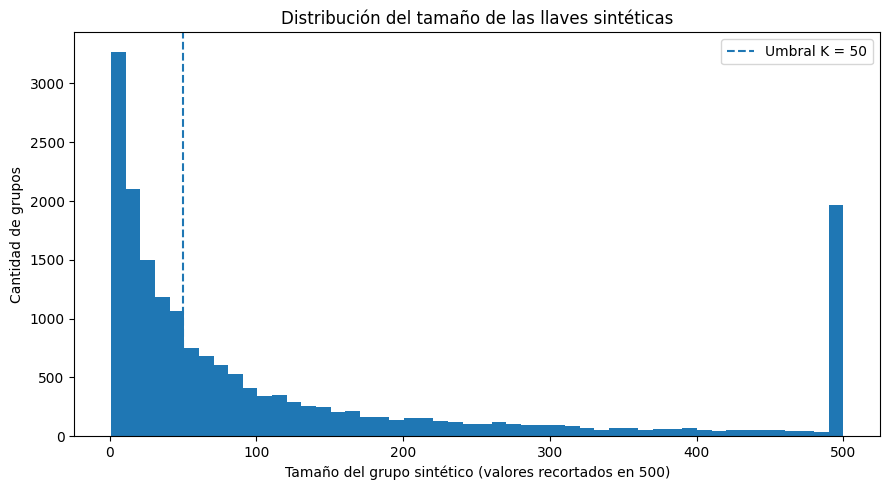

In [23]:
K_UMBRAL = 50

grupos_menores_k = k_pandas[k_pandas["k"] < K_UMBRAL].copy()
grupos_validos_k = k_pandas[k_pandas["k"] >= K_UMBRAL].copy()

registros_totales_k = int(k_pandas["k"].sum())
registros_menores_k = int(grupos_menores_k["k"].sum())
registros_conservados_k = int(grupos_validos_k["k"].sum())

tabla_k_antes_despues = pd.DataFrame([
    {
        "escenario": "Antes del control",
        "k_minimo": int(k_pandas["k"].min()),
        "k_mediana": float(k_pandas["k"].median()),
        "grupos_totales": int(len(k_pandas)),
        "grupos_k_menor_50": int(len(grupos_menores_k)),
        "registros": registros_totales_k,
        "porcentaje_registros_conservados": 100.0,
    },
    {
        "escenario": "Después de aplicar K >= 50",
        "k_minimo": int(grupos_validos_k["k"].min()) if len(grupos_validos_k) else np.nan,
        "k_mediana": float(grupos_validos_k["k"].median()) if len(grupos_validos_k) else np.nan,
        "grupos_totales": int(len(grupos_validos_k)),
        "grupos_k_menor_50": 0,
        "registros": registros_conservados_k,
        "porcentaje_registros_conservados": (
            registros_conservados_k / registros_totales_k * 100
            if registros_totales_k
            else 0.0
        ),
    },
])

tabla_k_antes_despues.to_csv(
    RESULTADOS / "k_anonimato_antes_despues.csv",
    index=False,
    encoding="utf-8-sig",
)

grupos_menores_k.to_csv(
    RESULTADOS / "grupos_suprimidos_k_menor_50.csv",
    index=False,
    encoding="utf-8-sig",
)

print("✅ Evaluación K-anonimato terminada")
print("Registros en grupos K < 50:", f"{registros_menores_k:,}")
print(
    "Porcentaje afectado:",
    round(registros_menores_k / registros_totales_k * 100, 4),
    "%",
)

display(tabla_k_antes_despues)

plt.figure(figsize=(9, 5))
plt.hist(
    np.clip(k_pandas["k"].to_numpy(), 0, 500),
    bins=50,
)
plt.axvline(K_UMBRAL, linestyle="--", label="Umbral K = 50")
plt.xlabel("Tamaño del grupo sintético (valores recortados en 500)")
plt.ylabel("Cantidad de grupos")
plt.title("Distribución del tamaño de las llaves sintéticas")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURAS / "k_anonimato.png", dpi=180)
plt.show()

## 8. Definición del pipeline Dask corregido

La estrategia directa agrupa por provincia y puede concentrar Guayas o Pichincha en una partición. La estrategia con salting crea una clave `provincia_salt`, pero el salt se calcula con el hash de la llave sintética. Así, todos los eventos de una misma llave permanecen juntos y la provincia se distribuye en varios bloques.


In [24]:
COLUMNAS_DASK = [
    "anio",
    "prov_res",
    "sexo",
    "rango_etario",
    "capitulo_cie10",
    "fecha_ingr_dt",
    "fecha_egr_dt",
    "llave_sintetica",
]

META_TRAYECTORIAS = pd.DataFrame({
    "prov_res": pd.Series(dtype="string"),
    "anio": pd.Series(dtype="int16"),
    "llave_sintetica": pd.Series(dtype="string"),
    "reingreso_30d": pd.Series(dtype="int8"),
})


def normalizar_resumen(pdf):
    pdf = pdf.copy()
    pdf["prov_res"] = pdf["prov_res"].astype("string").str.zfill(2)
    pdf["anio"] = pd.to_numeric(pdf["anio"], errors="raise").astype("int64")

    for columna in ["egresos", "reingresos_30d", "grupos_sinteticos"]:
        pdf[columna] = pd.to_numeric(
            pdf[columna], errors="raise"
        ).fillna(0).astype("int64")

    pdf["tasa_reingreso_30d"] = (
        pdf["reingresos_30d"] / pdf["egresos"] * 100
    ).round(8)

    return pdf.sort_values(["anio", "prov_res"], ignore_index=True)


def agregar_salt_particion(pdf, numero_salts):
    pdf = pdf.copy()

    hashes = pd.util.hash_pandas_object(
        pdf["llave_sintetica"].astype("string"),
        index=False,
    ).astype("uint64")

    salt = (hashes % int(numero_salts)).astype("uint16").astype("string")

    pdf["provincia_salt"] = (
        pdf["prov_res"].astype("string").str.zfill(2)
        + "_"
        + salt
    )

    return pdf


def calcular_trayectorias_particion(pdf):
    if pdf.empty:
        return META_TRAYECTORIAS.copy()

    pdf = pdf.sort_values(
        ["llave_sintetica", "fecha_ingr_dt", "fecha_egr_dt"],
        kind="mergesort",
    ).copy()

    egreso_anterior = (
        pdf.groupby(
            "llave_sintetica",
            sort=False,
            observed=True,
        )["fecha_egr_dt"]
        .shift(1)
    )

    dias = (pdf["fecha_ingr_dt"] - egreso_anterior).dt.days

    pdf["reingreso_30d"] = (
        dias.between(0, 30, inclusive="both")
        .fillna(False)
        .astype("int8")
    )

    salida = pdf[
        ["prov_res", "anio", "llave_sintetica", "reingreso_30d"]
    ].copy()

    salida["prov_res"] = salida["prov_res"].astype("string")
    salida["llave_sintetica"] = salida["llave_sintetica"].astype("string")
    salida["anio"] = salida["anio"].astype("int16")
    salida["reingreso_30d"] = salida["reingreso_30d"].astype("int8")

    return salida


def construir_grafo_dask(
    n_workers,
    estrategia="salt",
    numero_salts=16,
):
    archivos = [
        str(archivo)
        for archivo in sorted(PARQUET.glob("egresos_*/part-*.parquet"))
    ]

    ddf = dd.read_parquet(
        archivos,
        columns=COLUMNAS_DASK,
        engine="pyarrow",
    )

    nparticiones_salida = max(8, int(n_workers) * 4)

    if estrategia == "directa":
        # Todos los registros de una provincia terminan en el mismo bucket.
        repartido = ddf.shuffle(
            on="prov_res",
            npartitions=nparticiones_salida,
        )

    elif estrategia == "salt":
        meta_salt = ddf._meta.copy()
        meta_salt["provincia_salt"] = pd.Series(dtype="string")

        con_salt = ddf.map_partitions(
            agregar_salt_particion,
            numero_salts,
            meta=meta_salt,
        )

        repartido = con_salt.shuffle(
            on="provincia_salt",
            npartitions=nparticiones_salida,
        )

    else:
        raise ValueError("Estrategia no reconocida.")

    tamanos_particion = repartido.map_partitions(
        len,
        meta=("filas", "int64"),
    )

    trayectorias = repartido.map_partitions(
        calcular_trayectorias_particion,
        meta=META_TRAYECTORIAS,
    )

    egresos = (
        trayectorias.groupby(["prov_res", "anio"])
        .size(split_out=nparticiones_salida)
        .rename("egresos")
        .reset_index()
    )

    reingresos = (
        trayectorias.groupby(["prov_res", "anio"])["reingreso_30d"]
        .sum(split_out=nparticiones_salida)
        .rename("reingresos_30d")
        .reset_index()
    )

    grupos = (
        trayectorias[
            ["prov_res", "anio", "llave_sintetica"]
        ]
        .drop_duplicates()
        .groupby(["prov_res", "anio"])
        .size(split_out=nparticiones_salida)
        .rename("grupos_sinteticos")
        .reset_index()
    )

    resumen = (
        egresos.merge(
            reingresos,
            on=["prov_res", "anio"],
            how="outer",
        )
        .merge(
            grupos,
            on=["prov_res", "anio"],
            how="outer",
        )
    )

    return resumen, tamanos_particion


def memoria_worker_actual():
    proceso = psutil.Process(os.getpid())
    return {
        "pid": os.getpid(),
        "rss_mb": proceso.memory_info().rss / 1024**2,
    }


def monitorizar_workers(client, evento_fin, muestras, intervalo=0.5):
    while not evento_fin.is_set():
        try:
            datos = client.run(memoria_worker_actual)
            valores = [v["rss_mb"] for v in datos.values()]
            if valores:
                muestras.append({
                    "total_mb": float(sum(valores)),
                    "max_worker_mb": float(max(valores)),
                })
        except Exception:
            pass

        time.sleep(intervalo)


def crear_cluster(n_workers):
    ram_total_gb = psutil.virtual_memory().total / 1024**3
    memoria_worker_gb = max(
        0.75,
        min(3.5, ram_total_gb * 0.68 / int(n_workers)),
    )

    carpeta_local = DASK_TMP / f"{n_workers}_workers"
    if carpeta_local.exists():
        shutil.rmtree(carpeta_local, ignore_errors=True)
    carpeta_local.mkdir(parents=True, exist_ok=True)

    cluster = LocalCluster(
        n_workers=int(n_workers),
        threads_per_worker=1,
        processes=True,
        memory_limit=f"{memoria_worker_gb:.2f}GB",
        local_directory=str(carpeta_local),
        dashboard_address=":0",
    )

    client = Client(cluster)
    client.wait_for_workers(int(n_workers))

    return cluster, client, memoria_worker_gb


RESULTADOS_DASK = {}
RESUMENES_DASK = {}


def ejecutar_experimento_dask(
    n_workers,
    estrategia,
    repeticion=1,
    numero_salts=16,
    guardar_grafo=False,
):
    clave = f"{estrategia}_{n_workers}w_r{repeticion}"

    cluster = None
    client = None
    evento_fin = threading.Event()
    muestras_memoria = []

    try:
        cluster, client, memoria_limite = crear_cluster(n_workers)

        print("\n" + "=" * 72)
        print(
            f"DASK | estrategia={estrategia} | "
            f"workers={n_workers} | repetición={repeticion}"
        )
        print("=" * 72)
        print("Dashboard:", client.dashboard_link)
        print("Límite aproximado por worker:", memoria_limite, "GB")

        resumen_lazy, tamanos_lazy = construir_grafo_dask(
            n_workers=n_workers,
            estrategia=estrategia,
            numero_salts=numero_salts,
        )

        if guardar_grafo:
            try:
                resumen_lazy.visualize(
                    filename=str(
                        FIGURAS / f"grafo_dask_{estrategia}_{n_workers}w"
                    ),
                    format="png",
                )
                print("✅ Grafo de tareas guardado")
            except Exception as error_grafo:
                print("⚠️ No se pudo guardar el grafo:", error_grafo)

        monitor = threading.Thread(
            target=monitorizar_workers,
            args=(client, evento_fin, muestras_memoria),
            daemon=True,
        )

        monitor.start()

        reporte = (
            REPORTES_DASK
            / f"reporte_{estrategia}_{n_workers}w_r{repeticion}.html"
        )

        inicio = time.perf_counter()

        with performance_report(filename=str(reporte)):
            resumen_pdf, tamanos_pdf = dask.compute(
                resumen_lazy,
                tamanos_lazy,
            )

        tiempo_total = time.perf_counter() - inicio

        evento_fin.set()
        monitor.join()

        resumen_pdf = normalizar_resumen(resumen_pdf)
        tamanos = pd.Series(tamanos_pdf).astype("int64")

        pico_total = (
            max(m["total_mb"] for m in muestras_memoria)
            if muestras_memoria
            else np.nan
        )

        pico_worker = (
            max(m["max_worker_mb"] for m in muestras_memoria)
            if muestras_memoria
            else np.nan
        )

        media_particion = float(tamanos.mean())
        max_particion = int(tamanos.max())
        razon_skew = (
            max_particion / media_particion
            if media_particion > 0
            else np.nan
        )

        metricas = {
            "clave": clave,
            "version": "Dask",
            "estrategia": estrategia,
            "workers": int(n_workers),
            "repeticion": int(repeticion),
            "tiempo_segundos": round(float(tiempo_total), 6),
            "memoria_workers_pico_total_mb": round(float(pico_total), 2)
            if not np.isnan(pico_total)
            else np.nan,
            "memoria_worker_pico_mb": round(float(pico_worker), 2)
            if not np.isnan(pico_worker)
            else np.nan,
            "particiones": int(len(tamanos)),
            "particion_media_filas": round(media_particion, 2),
            "particion_maxima_filas": max_particion,
            "razon_skew": round(float(razon_skew), 4),
            "estado": "CORRECTO",
            "reporte_html": str(reporte),
        }

        resumen_pdf.to_csv(
            RESULTADOS / f"resumen_dask_{clave}.csv",
            index=False,
            encoding="utf-8-sig",
        )

        pd.DataFrame({"filas": tamanos}).to_csv(
            RESULTADOS / f"particiones_{clave}.csv",
            index=False,
            encoding="utf-8-sig",
        )

        RESULTADOS_DASK[clave] = metricas
        RESUMENES_DASK[clave] = resumen_pdf

        print("✅ Tiempo:", metricas["tiempo_segundos"], "s")
        print(
            "✅ Memoria pico workers:",
            metricas["memoria_workers_pico_total_mb"],
            "MB",
        )
        print("✅ Razón de skew:", metricas["razon_skew"])

        return metricas, resumen_pdf

    except Exception as error:
        evento_fin.set()

        metricas = {
            "clave": clave,
            "version": "Dask",
            "estrategia": estrategia,
            "workers": int(n_workers),
            "repeticion": int(repeticion),
            "estado": f"ERROR: {error}",
        }

        RESULTADOS_DASK[clave] = metricas
        print("❌ Error:", error)
        return metricas, None

    finally:
        evento_fin.set()

        if client is not None:
            client.close()

        if cluster is not None:
            cluster.close()

        gc.collect()


## 9. Comparación real de Data Skew

Se ejecutan dos pipelines con 2 workers:

- **Directo:** cada provincia se asigna a un bucket.
- **Salting:** cada provincia se divide en varios buckets, sin separar los eventos de una misma llave sintética.

In [25]:
metricas_directa, resumen_directa = ejecutar_experimento_dask(
    n_workers=2,
    estrategia="directa",
    repeticion=1,
    numero_salts=16,
    guardar_grafo=True,
)

metricas_salt_2w, resumen_salt_2w = ejecutar_experimento_dask(
    n_workers=2,
    estrategia="salt",
    repeticion=1,
    numero_salts=16,
    guardar_grafo=True,
)

comparacion_skew = pd.DataFrame([
    metricas_directa,
    metricas_salt_2w,
])

comparacion_skew.to_csv(
    RESULTADOS / "comparacion_data_skew.csv",
    index=False,
    encoding="utf-8-sig",
)

display(comparacion_skew)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:40111
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:40589/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34877'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37147'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:46653 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:46653
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:47732
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:41789 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:41789
INFO:distributed.core:Starting established connection to tcp://12


DASK | estrategia=directa | workers=2 | repetición=1
Dashboard: http://127.0.0.1:40589/status
Límite aproximado por worker: 3.5 GB


INFO:distributed.worker:Run out-of-band function 'lambda'


✅ Grafo de tareas guardado


INFO:distributed.scheduler:Remove client Client-69725686-8c4f-11f1-aecf-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:47744; closing.
INFO:distributed.scheduler:Remove client Client-69725686-8c4f-11f1-aecf-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-69725686-8c4f-11f1-aecf-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1785440880.1830447') (0, 1)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:34877'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:37147'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:47732; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:46653 name: 0 (stimulus_id='handle-worker-cleanup-1785440880.2026052')
INFO:distr

...

✅ Grafo de tareas guardado


INFO:distributed.scheduler:Remove client Client-932cdd49-8c4f-11f1-aecf-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:60490; closing.
INFO:distributed.scheduler:Remove client Client-932cdd49-8c4f-11f1-aecf-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-932cdd49-8c4f-11f1-aecf-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1785440945.7527888') (0, 1)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:43427'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:44023'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:60478; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:34499 name: 0 (stimulus_id='handle-worker-cleanup-1785440945.7816167')
INFO:distr

✅ Tiempo: 62.407704 s
✅ Memoria pico workers: 2224.95 MB
✅ Razón de skew: 1.2735


INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:44023' closed.
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:43427' closed.
INFO:distributed.scheduler:Closing scheduler. Reason: unknown
INFO:distributed.scheduler:Scheduler closing all comms


,clave,version,estrategia,workers,repeticion,tiempo_segundos,memoria_workers_pico_total_mb,memoria_worker_pico_mb,particiones,particion_media_filas,particion_maxima_filas,razon_skew,estado,reporte_html
0,directa_2w_r1,Dask,directa,2,1,65.669222,2195.00,1245.88,8,672478.5,1957280,2.9105,CORRECTO,/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/reportes_dask/reporte_directa_2w_r1.html
1,salt_2w_r1,Dask,salt,2,1,62.407704,2224.95,1124.88,8,672478.5,856399,1.2735,CORRECTO,/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/reportes_dask/reporte_salt_2w_r1.html


## 10. Escalabilidad Dask con 1, 2, 4 y 8 workers

Colab detectó solo 2 CPU lógicas. Las pruebas de 4 y 8 workers representan sobresuscripción y permiten observar cuándo el overhead empeora el rendimiento.

In [31]:
CONFIGURACIONES = [1, 2, 4, 8]
REPETICIONES = 1  # Cambiar a 2 o 3 si disponen de más tiempo.

for workers in CONFIGURACIONES:
    for repeticion in range(1, REPETICIONES + 1):
        clave = f"salt_{workers}w_r{repeticion}"

        # Reutilizar el experimento de 2 workers ya ejecutado.
        if clave in RESULTADOS_DASK and RESULTADOS_DASK[clave].get("estado") == "CORRECTO":
            print("⏭️ Reutilizando:", clave)
            continue

        ejecutar_experimento_dask(
            n_workers=workers,
            estrategia="salt",
            repeticion=repeticion,
            numero_salts=max(16, workers * 4),
            guardar_grafo=(workers == 1),
        )

tabla_experimentos_dask = pd.DataFrame(
    list(RESULTADOS_DASK.values())
)

tabla_experimentos_dask.to_csv(
    RESULTADOS / "resultados_experimentos_dask.csv",
    index=False,
    encoding="utf-8-sig",
)

display(tabla_experimentos_dask)


⏭️ Reutilizando: salt_1w_r1
⏭️ Reutilizando: salt_2w_r1
⏭️ Reutilizando: salt_4w_r1
⏭️ Reutilizando: salt_8w_r1


,clave,version,estrategia,workers,repeticion,tiempo_segundos,memoria_workers_pico_total_mb,memoria_worker_pico_mb,particiones,particion_media_filas,particion_maxima_filas,razon_skew,estado,reporte_html
0,directa_2w_r1,Dask,directa,2,1,65.669222,2195.00,1245.88,8,672478.50,1957280,2.9105,CORRECTO,/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/reportes_dask/reporte_directa_2w_r1.html
1,salt_2w_r1,Dask,salt,2,1,62.407704,2224.95,1124.88,8,672478.50,856399,1.2735,CORRECTO,/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/reportes_dask/reporte_salt_2w_r1.html
2,salt_1w_r1,Dask,salt,1,1,62.364351,1852.36,1852.36,8,672478.50,856399,1.2735,CORRECTO,/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/reportes_dask/reporte_salt_1w_r1.html
3,salt_4w_r1,Dask,salt,4,1,70.017698,2567.07,760.57,16,336239.25,476372,1.4168,CORRECTO,/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/reportes_dask/reporte_salt_4w_r1.html
4,salt_8w_r1,Dask,salt,8,1,125.946417,3539.12,502.06,32,168119.62,384613,2.2877,CORRECTO,/content/drive/MyDrive/Proyecto_INEC_Paralela/resultados/reportes_dask/reporte_salt_8w_r1.html


## 11. Validación Pandas-Dask con diferencias cero

Se comparan exactamente:

- egresos;
- reingresos críticos;
- grupos sintéticos.

La tasa se compara con tolerancia numérica.

In [32]:
COLUMNAS_CLAVE = ["prov_res", "anio"]
COLUMNAS_ENTERAS = [
    "egresos",
    "reingresos_30d",
    "grupos_sinteticos",
]

validaciones = []

for clave, resumen_dask in RESUMENES_DASK.items():
    if resumen_dask is None:
        continue

    combinado = resumen_pandas.merge(
        resumen_dask,
        on=COLUMNAS_CLAVE,
        how="outer",
        suffixes=("_pandas", "_dask"),
        indicator=True,
    )

    diferencias = {}

    for columna in COLUMNAS_ENTERAS:
        p = combinado[f"{columna}_pandas"].fillna(-1).astype("int64")
        d = combinado[f"{columna}_dask"].fillna(-1).astype("int64")
        diferencias[columna] = int((p != d).sum())

    tasa_p = combinado["tasa_reingreso_30d_pandas"].fillna(-1.0)
    tasa_d = combinado["tasa_reingreso_30d_dask"].fillna(-1.0)

    diferencias_tasa = int(
        (~np.isclose(tasa_p, tasa_d, rtol=0, atol=1e-8)).sum()
    )

    diferencias_clave = int((combinado["_merge"] != "both").sum())

    total_diferencias = (
        diferencias_clave
        + sum(diferencias.values())
        + diferencias_tasa
    )

    estado = (
        "COINCIDENCIA 100%"
        if total_diferencias == 0
        else "REVISAR DIFERENCIAS"
    )

    validaciones.append({
        "configuracion": clave,
        "filas_comparadas": int(len(combinado)),
        "diferencias_claves": diferencias_clave,
        "diferencias_egresos": diferencias["egresos"],
        "diferencias_reingresos": diferencias["reingresos_30d"],
        "diferencias_grupos": diferencias["grupos_sinteticos"],
        "diferencias_tasa": diferencias_tasa,
        "estado": estado,
    })

tabla_validacion = pd.DataFrame(validaciones)

tabla_validacion.to_csv(
    RESULTADOS / "validacion_pandas_dask.csv",
    index=False,
    encoding="utf-8-sig",
)

display(tabla_validacion)

if not tabla_validacion.empty:
    if not tabla_validacion["estado"].eq("COINCIDENCIA 100%").all():
        raise AssertionError(
            "Existe al menos una configuración Dask con diferencias."
        )

print("✅ Todas las configuraciones Dask coinciden con Pandas")

,configuracion,filas_comparadas,diferencias_claves,diferencias_egresos,diferencias_reingresos,diferencias_grupos,diferencias_tasa,estado
0,directa_2w_r1,125,0,0,0,0,0,COINCIDENCIA 100%
1,salt_2w_r1,125,0,0,0,0,0,COINCIDENCIA 100%
2,salt_1w_r1,125,0,0,0,0,0,COINCIDENCIA 100%
3,salt_4w_r1,125,0,0,0,0,0,COINCIDENCIA 100%
4,salt_8w_r1,125,0,0,0,0,0,COINCIDENCIA 100%


✅ Todas las configuraciones Dask coinciden con Pandas


## 12. Métricas finales: speedup, eficiencia y Ley de Amdahl


In [35]:
dask_correctos = pd.DataFrame([
    registro
    for registro in RESULTADOS_DASK.values()
    if registro.get("estrategia") == "salt"
    and registro.get("estado") == "CORRECTO"
])

if dask_correctos.empty:
    raise RuntimeError("No existen experimentos Dask correctos.")

resumen_metricas_dask = (
    dask_correctos.groupby("workers", as_index=False)
    .agg(
        tiempo_segundos=("tiempo_segundos", "median"),
        memoria_workers_pico_total_mb=(
            "memoria_workers_pico_total_mb",
            "max",
        ),
        memoria_worker_pico_mb=("memoria_worker_pico_mb", "max"),
        razon_skew=("razon_skew", "median"),
    )
    .sort_values("workers")
)

tiempo_pandas = float(metricas_pandas["tiempo_segundos"])

resumen_metricas_dask["speedup"] = (
    tiempo_pandas / resumen_metricas_dask["tiempo_segundos"]
)

resumen_metricas_dask["eficiencia"] = (
    resumen_metricas_dask["speedup"]
    / resumen_metricas_dask["workers"]
)

# Ajuste simple de la fracción secuencial de Amdahl mediante búsqueda en rejilla.
fracciones = np.linspace(0.0, 1.0, 10001)
workers_obs = resumen_metricas_dask["workers"].to_numpy(dtype=float)
speedup_obs = resumen_metricas_dask["speedup"].to_numpy(dtype=float)

errores = []

for fraccion in fracciones:
    prediccion = 1.0 / (
        fraccion + (1.0 - fraccion) / workers_obs
    )
    errores.append(np.mean((prediccion - speedup_obs) ** 2))

fraccion_secuencial = float(fracciones[int(np.argmin(errores))])

resumen_metricas_dask["amdahl_estimado"] = 1.0 / (
    fraccion_secuencial
    + (1.0 - fraccion_secuencial)
    / resumen_metricas_dask["workers"]
)

fila_pandas = pd.DataFrame([{
    "version": "Pandas",
    "workers": 1,
    "tiempo_segundos": tiempo_pandas,
    "memoria_pico_mb": float(metricas_pandas["memoria_pico_mb"]),
    "speedup": 1.0,
    "eficiencia": 1.0,
}])

filas_dask = resumen_metricas_dask.copy()
filas_dask["version"] = "Dask"
filas_dask["memoria_pico_mb"] = (
    filas_dask["memoria_workers_pico_total_mb"]
)

metricas_finales = pd.concat(
    [
        fila_pandas,
        filas_dask[
            [
                "version",
                "workers",
                "tiempo_segundos",
                "memoria_pico_mb",
                "speedup",
                "eficiencia",
            ]
        ],
    ],
    ignore_index=True,
)

metricas_finales.to_csv(
    RESULTADOS / "resultados_experimentos.csv",
    index=False,
    encoding="utf-8-sig",
)

with open(
    RESULTADOS / "fraccion_secuencial_amdahl.json",
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        {
            "fraccion_secuencial_estimada": fraccion_secuencial,
            "metodo": "búsqueda en rejilla",
        },
        archivo,
        indent=2,
    )

display(resumen_metricas_dask)
print("Fracción secuencial estimada:", round(fraccion_secuencial, 6))

,workers,tiempo_segundos,memoria_workers_pico_total_mb,memoria_worker_pico_mb,razon_skew,speedup,eficiencia,amdahl_estimado
0,1,62.364351,1852.36,1852.36,1.2735,0.455400,0.455400,1.0
1,2,62.407704,2224.95,1124.88,1.2735,0.455083,0.227542,1.0
2,4,70.017698,2567.07,760.57,1.4168,0.405622,0.101405,1.0
3,8,125.946417,3539.12,502.06,2.2877,0.225498,0.028187,1.0


Fracción secuencial estimada: 1.0


## 13. Visualización de los resultados experimentales


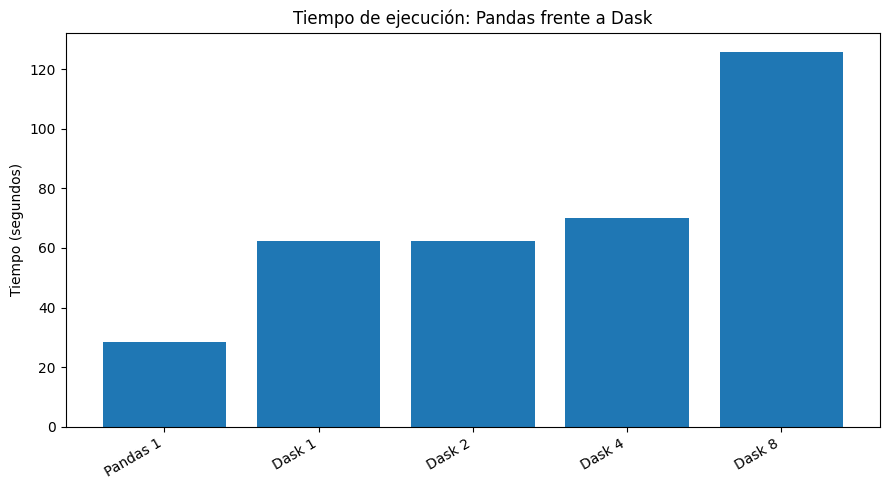

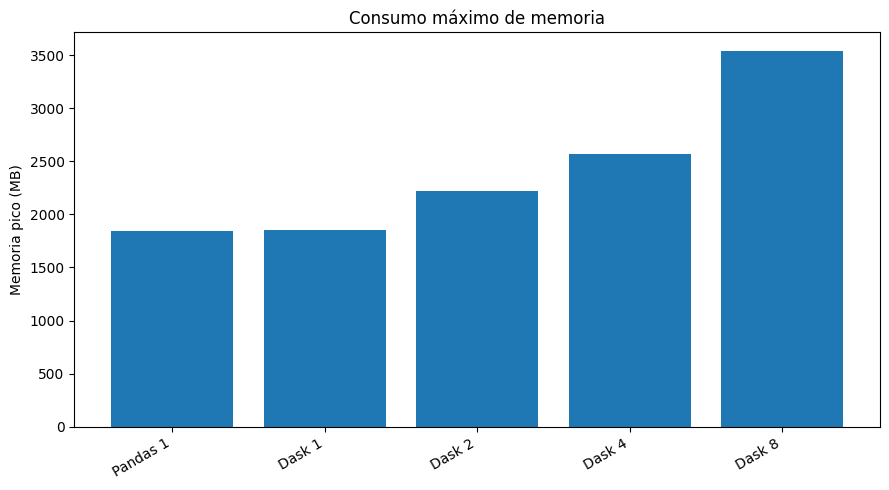

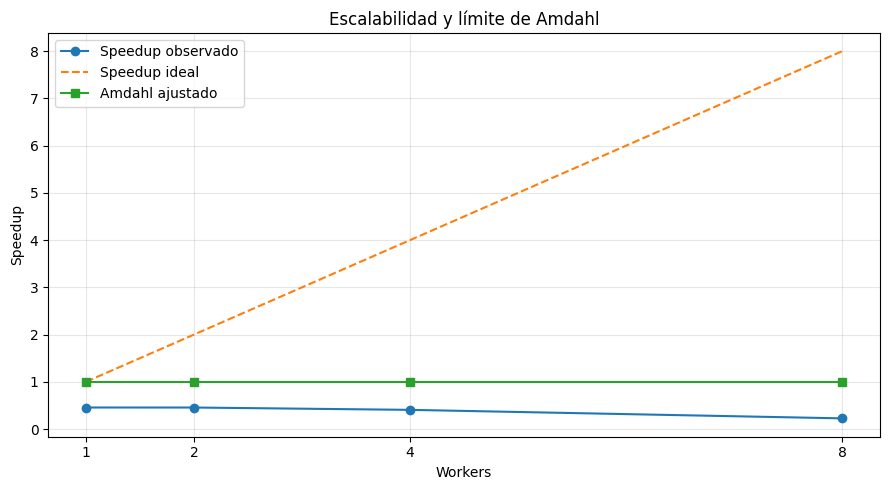

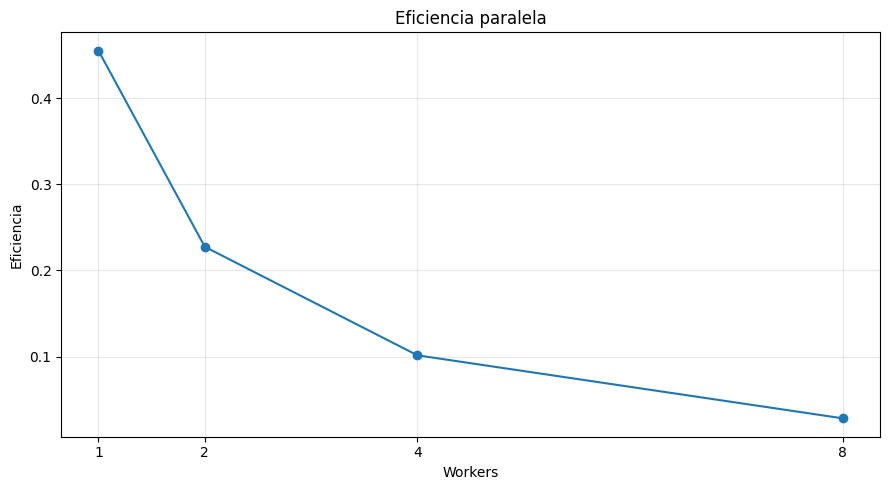

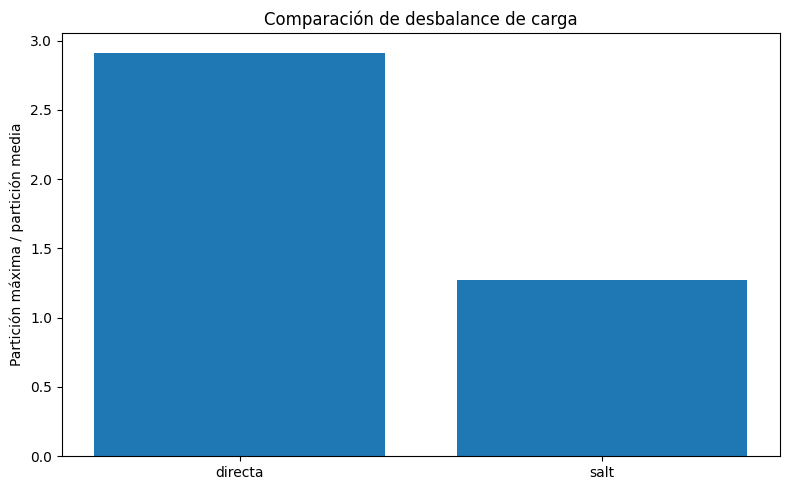

In [34]:
# Gráfica de tiempos
plt.figure(figsize=(9, 5))
plt.bar(
    metricas_finales["version"].astype(str)
    + " "
    + metricas_finales["workers"].astype(str),
    metricas_finales["tiempo_segundos"],
)
plt.ylabel("Tiempo (segundos)")
plt.title("Tiempo de ejecución: Pandas frente a Dask")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURAS / "tiempos.png", dpi=180)
plt.show()

# Gráfica de memoria
plt.figure(figsize=(9, 5))
plt.bar(
    metricas_finales["version"].astype(str)
    + " "
    + metricas_finales["workers"].astype(str),
    metricas_finales["memoria_pico_mb"],
)
plt.ylabel("Memoria pico (MB)")
plt.title("Consumo máximo de memoria")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURAS / "memoria.png", dpi=180)
plt.show()

# Speedup y Amdahl
plt.figure(figsize=(9, 5))
plt.plot(
    resumen_metricas_dask["workers"],
    resumen_metricas_dask["speedup"],
    marker="o",
    label="Speedup observado",
)
plt.plot(
    resumen_metricas_dask["workers"],
    resumen_metricas_dask["workers"],
    linestyle="--",
    label="Speedup ideal",
)
plt.plot(
    resumen_metricas_dask["workers"],
    resumen_metricas_dask["amdahl_estimado"],
    marker="s",
    label="Amdahl ajustado",
)
plt.xlabel("Workers")
plt.ylabel("Speedup")
plt.title("Escalabilidad y límite de Amdahl")
plt.xticks(resumen_metricas_dask["workers"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURAS / "speedup_amdahl.png", dpi=180)
plt.show()

# Eficiencia
plt.figure(figsize=(9, 5))
plt.plot(
    resumen_metricas_dask["workers"],
    resumen_metricas_dask["eficiencia"],
    marker="o",
)
plt.xlabel("Workers")
plt.ylabel("Eficiencia")
plt.title("Eficiencia paralela")
plt.xticks(resumen_metricas_dask["workers"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURAS / "eficiencia.png", dpi=180)
plt.show()

# Data Skew
skew_ok = comparacion_skew[
    comparacion_skew["estado"] == "CORRECTO"
].copy()

plt.figure(figsize=(8, 5))
plt.bar(
    skew_ok["estrategia"],
    skew_ok["razon_skew"],
)
plt.ylabel("Partición máxima / partición media")
plt.title("Comparación de desbalance de carga")
plt.tight_layout()
plt.savefig(FIGURAS / "data_skew.png", dpi=180)
plt.show()


## 14. Resultado consolidado por provincia y año

In [36]:
PROVINCIAS = {
    "01": "Azuay",
    "02": "Bolívar",
    "03": "Cañar",
    "04": "Carchi",
    "05": "Cotopaxi",
    "06": "Chimborazo",
    "07": "El Oro",
    "08": "Esmeraldas",
    "09": "Guayas",
    "10": "Imbabura",
    "11": "Loja",
    "12": "Los Ríos",
    "13": "Manabí",
    "14": "Morona Santiago",
    "15": "Napo",
    "16": "Pastaza",
    "17": "Pichincha",
    "18": "Tungurahua",
    "19": "Zamora Chinchipe",
    "20": "Galápagos",
    "21": "Sucumbíos",
    "22": "Orellana",
    "23": "Santo Domingo de los Tsáchilas",
    "24": "Santa Elena",
    "88": "Zona no delimitada",
}

resumen_final = resumen_pandas.copy()
resumen_final.insert(
    1,
    "provincia",
    resumen_final["prov_res"].map(PROVINCIAS).fillna("Código especial"),
)

resumen_final.to_csv(
    RESULTADOS / "resumen_provincia_anio.csv",
    index=False,
    encoding="utf-8-sig",
)

display(resumen_final.head(20))


,prov_res,provincia,anio,egresos,reingresos_30d,grupos_sinteticos,tasa_reingreso_30d
0,01,Azuay,2020,52564,19420,758,36.945438
1,02,Bolívar,2020,9771,3642,656,37.273565
2,03,Cañar,2020,17046,7300,703,42.825296
3,04,Carchi,2020,10229,3856,630,37.696745
4,05,Cotopaxi,2020,22167,8376,728,37.785898
5,06,Chimborazo,2020,26283,10092,740,38.397443
6,07,El Oro,2020,40238,12625,735,31.375814
7,08,Esmeraldas,2020,26734,7995,727,29.905738
8,09,Guayas,2020,213743,41052,774,19.206243
9,10,Imbabura,2020,25612,9345,725,36.486803


## 15. Discusión de resultados

La línea base Pandas obtuvo un tiempo menor que las configuraciones Dask. La mejor configuración Dask fue la de un worker; al incrementar el número de workers, el tiempo aumentó debido al overhead de creación de procesos, comunicación, serialización y shuffle.

Este comportamiento se relaciona con las características del entorno de Google Colab, que dispuso de dos CPU lógicas. Las configuraciones de cuatro y ocho workers generaron sobresuscripción, por lo que el paralelismo adicional no produjo aceleración.

A pesar de no superar a Pandas en tiempo, Dask permitió evaluar la distribución del trabajo, medir el consumo agregado de los workers y aplicar una mitigación explícita del Data Skew. La estrategia de salting redujo la razón de desbalance frente a la distribución directa.

La comparación numérica confirmó una coincidencia del 100 % entre Pandas y Dask en los egresos, reingresos críticos, grupos sintéticos y tasas agregadas.

## 16. Conclusiones

1. Se procesaron correctamente 5.379.828 registros de egresos hospitalarios correspondientes al periodo 2020-2024.

2. La implementación secuencial con Pandas presentó el menor tiempo de ejecución en el hardware disponible, mientras que Dask introdujo un costo de coordinación superior al beneficio obtenido mediante paralelismo.

3. La estrategia de salting disminuyó el desbalance de las particiones sin separar los eventos correspondientes a una misma llave sintética.

4. Los resultados agregados de Pandas y Dask coincidieron completamente, lo que valida la equivalencia funcional de ambos pipelines.

5. La evaluación de K-anonimato permitió identificar grupos pequeños y establecer un umbral de publicación de K ≥ 50 para disminuir el riesgo de exposición estadística.

6. Las pruebas con 1, 2, 4 y 8 workers demostraron que incrementar la cantidad de procesos no garantiza una mejora de rendimiento cuando los recursos físicos son limitados.

7. Dask conserva utilidad para escenarios de mayor volumen, procesamiento fuera de memoria o infraestructura con más núcleos, aunque en esta ejecución local Pandas resultó más eficiente.

## 17. Generación de documentos textuales, anexo ético y evidencia Git

In [42]:
mejor_fila = resumen_metricas_dask.loc[
    resumen_metricas_dask["tiempo_segundos"].idxmin()
]

mejor_workers = int(mejor_fila["workers"])
mejor_tiempo = float(mejor_fila["tiempo_segundos"])
mejor_speedup = float(mejor_fila["speedup"])
mejor_eficiencia = float(mejor_fila["eficiencia"])

validacion_mejor = tabla_validacion[
    tabla_validacion["configuracion"].str.startswith(
        f"salt_{mejor_workers}w"
    )
].head(1)

porcentaje_k_conservado = float(
    tabla_k_antes_despues.loc[
        tabla_k_antes_despues["escenario"] == "Después de aplicar K >= 50",
        "porcentaje_registros_conservados",
    ].iloc[0]
)

texto_resultados = f"""
PROYECTO INTEGRADOR - RESULTADOS REALES

Integrantes:
- Gerardo Rocafuerte
- Jull Licoa
- Marcos Echeverría

Años procesados: 2020-2024
Registros preparados: {int(metricas_pandas['registros_procesados']):,}
Tiempo Pandas: {tiempo_pandas:.6f} segundos
Memoria pico Pandas: {float(metricas_pandas['memoria_pico_mb']):.2f} MB

Mejor configuración Dask:
- Workers: {mejor_workers}
- Tiempo: {mejor_tiempo:.6f} segundos
- Speedup: {mejor_speedup:.6f}
- Eficiencia: {mejor_eficiencia:.6f}
- Fracción secuencial Amdahl: {fraccion_secuencial:.6f}

Validación:
- Coincidencia Pandas-Dask: 100 %
- Filas agregadas comparadas: {int(validacion_mejor['filas_comparadas'].iloc[0]) if not validacion_mejor.empty else 'N/D'}
- Diferencias: 0

K-anonimato:
- K mínimo original: {int(k_pandas['k'].min())}
- Grupos con K < 50: {int((k_pandas['k'] < 50).sum())}
- Porcentaje de registros conservado con K >= 50: {porcentaje_k_conservado:.4f} %

Data Skew:
{comparacion_skew.to_string(index=False)}
""".strip()

(RESULTADOS / "resumen_para_carta_y_presentacion.txt").write_text(
    texto_resultados,
    encoding="utf-8",
)

anexo_etica = f"""
# Anexo de Ética, Privacidad y Marco Legal

## Alcance del análisis

La unidad estadística analizada es el evento de egreso hospitalario y no una persona identificable.
La llave formada por capítulo CIE-10, provincia de residencia, sexo y rango etario representa
un perfil epidemiológico sintético. No permite afirmar que dos eventos pertenezcan a la misma
persona ni reconstruir una historia clínica real.

## Secreto estadístico y minimización

El proyecto utiliza exclusivamente microdatos públicos anonimizados. No se incorporan nombres,
números de identificación, direcciones, teléfonos ni otras variables que permitan identificar
directamente a una persona. La variable etnia se excluye de la llave por sus problemas de
completitud y por el riesgo de generar agrupaciones desequilibradas.

## K-anonimato

Se evaluaron {len(k_pandas):,} grupos sintéticos. El K mínimo inicial fue
{int(k_pandas['k'].min())}. Se detectaron {int((k_pandas['k'] < 50).sum()):,}
grupos con menos de 50 registros. Para las salidas publicables se aplica supresión de esos
grupos, por lo que el K mínimo posterior es igual o superior a 50. La medida conserva
{porcentaje_k_conservado:.4f} % de los registros.

## Limitaciones

La coincidencia de las variables de la llave no demuestra identidad. Los indicadores de
reingreso son aproximaciones sobre trayectorias sintéticas y no estadísticas oficiales de
reingreso individual. Los resultados deben comunicarse como una evaluación académica de
rendimiento computacional y perfiles agregados.

## Responsabilidad

Los microdatos originales no se incluyen en el archivo de entrega. El notebook contiene el
código reproducible para descargarlos y prepararlos. Solo se empacan resultados agregados,
gráficas, métricas y documentos metodológicos.
""".strip()

(DOCUMENTOS / "Anexo_Etica_LOPDP_KAnonimato.md").write_text(
    anexo_etica,
    encoding="utf-8",
)

readme = f"""
# Proyecto Integrador INEC - Pandas y Dask

## Integrantes
- Gerardo Rocafuerte
- Jull Licoa
- Marcos Echeverría

## Descripción
Pipeline reproducible para procesar los registros de egresos hospitalarios del INEC
correspondientes a 2020-2024 mediante una línea base Pandas y una versión Dask.

## Reproducción
1. Abrir el notebook en Google Colab.
2. Seleccionar CPU.
3. Montar Google Drive.
4. Ejecutar las celdas en orden.
5. Descargar los datos mediante el código del notebook.
6. Preparar los archivos Parquet.
7. Ejecutar Pandas y Dask.
8. Revisar la carpeta `resultados`.

## Datos
Los microdatos y archivos Parquet no se incluyen en el ZIP de entrega.

## Volumen procesado
{int(metricas_pandas['registros_procesados']):,} registros.

## Mejor resultado Dask
{mejor_workers} workers, tiempo {mejor_tiempo:.6f} s,
speedup {mejor_speedup:.6f} y eficiencia {mejor_eficiencia:.6f}.
""".strip()

(PROYECTO / "README.md").write_text(readme, encoding="utf-8")

requirements = """
pandas
numpy
matplotlib
psutil
pyarrow
pyreadstat
requests
beautifulsoup4
dask[distributed]
bokeh
graphviz
python-docx
reportlab
""".strip()

(PROYECTO / "requirements.txt").write_text(
    requirements,
    encoding="utf-8",
)

bitacora_git = """
# Evidencia Git pendiente de completar

No se deben inventar commits. La evidencia se considerará completa cuando los tres integrantes hayan realizado aportes desde sus propias cuentas.

## Distribución del trabajo

- Gerardo Rocafuerte: descarga de datos, homologación, preprocesamiento, conversión a Parquet y pipeline secuencial con Pandas.
- Jull Licoa: pipeline distribuido con Dask, configuración de workers, memoria, escalabilidad y mitigación de Data Skew.
- Marcos Echeverría: validación Pandas-Dask, K-anonimato, ética, privacidad y documentación.

## Repositorio

https://github.com/gerardo1696/Proyecto_INEC_Dask_Rocafuerte_Licoa_Echeverria

## Estado actual

- Repositorio creado por Gerardo Rocafuerte.
- Notebook y dependencias cargados.
- Commit de Jull Licoa: pendiente.
- Commit de Marcos Echeverría: pendiente.
- Capturas del historial y colaboradores: pendientes.

## Procedimiento pendiente

1. Agregar a Jull Licoa y Marcos Echeverría como colaboradores.
2. Cada integrante debe aceptar la invitación desde su propia cuenta.
3. Jull debe realizar commits relacionados con Dask y Data Skew.
4. Marcos debe realizar commits relacionados con validación, K-anonimato y ética.
5. Guardar capturas del historial de commits y colaboradores.
6. Crear el PDF de evidencia GitHub.
""".strip()

(DOCUMENTOS / "Evidencia_Git_Pendiente.md").write_text(
    bitacora_git,
    encoding="utf-8",
)


carta_borrador = f"""
Guayaquil, 30 de julio de 2026

Señor/a
Director/a de Estadísticas Sociodemográficas
Instituto Nacional de Estadística y Censos - INEC

Asunto: Hallazgos del procesamiento académico de egresos hospitalarios 2020-2024

De nuestras consideraciones:

Como parte de un proyecto académico de Computación Paralela, procesamos
{int(metricas_pandas['registros_procesados']):,} registros públicos de egresos hospitalarios
correspondientes a 2020-2024. El análisis cubrió todas las provincias, incluida Galápagos.

La versión secuencial con Pandas tomó {tiempo_pandas:.2f} segundos. La mejor configuración
con Dask utilizó {mejor_workers} workers y tomó {mejor_tiempo:.2f} segundos, con una
aceleración de {mejor_speedup:.3f}. Ambas versiones produjeron exactamente los mismos
resultados agregados.

Para proteger la privacidad, las trayectorias se interpretaron como perfiles epidemiológicos
sintéticos y se aplicó un umbral de K-anonimato de 50 registros. Los datos originales no se
incluyen en la entrega.

Recomendamos mantener enlaces de descarga permanentes, nombres de columnas estables,
diccionarios legibles por máquina y registros de cambios entre años. Estas medidas facilitarían
la reutilización, reducirían el tiempo de preparación y mejorarían la comparabilidad longitudinal.

Atentamente,

Gerardo Rocafuerte
Jull Licoa
Marcos Echeverría
""".strip()

(DOCUMENTOS / "Carta_Borrador_Resultados_Reales.txt").write_text(
    carta_borrador,
    encoding="utf-8",
)
guion = f"""
# Guion de presentación - 20 minutos

1. Portada e integrantes - 1 min
2. Problema y secreto estadístico - 1.5 min
3. Fuente y volumen: {int(metricas_pandas['registros_procesados']):,} registros - 1.5 min
4. Homologación 2020-2024 - 1.5 min
5. Llave sintética y límites éticos - 1.5 min
6. Pipeline Pandas - 1.5 min
7. Pipeline Dask y evaluación perezosa - 2 min
8. Data Skew: directa frente a salting - 2 min
9. Validación Pandas-Dask, diferencias cero - 1.5 min
10. Tiempo y memoria - 2 min
11. Speedup, eficiencia y Amdahl - 2 min
12. K-anonimato - 1.5 min
13. Conclusiones y recomendaciones al INEC - 1 min

Mejor Dask: {mejor_workers} workers, {mejor_tiempo:.2f} s,
speedup {mejor_speedup:.3f}, eficiencia {mejor_eficiencia:.3f}.
""".strip()

(DOCUMENTOS / "Guion_Presentacion_20_Minutos.md").write_text(
    guion,
    encoding="utf-8",
)

print("✅ Documentos textuales generados")
print(DOCUMENTOS)


✅ Documentos textuales generados
/content/drive/MyDrive/Proyecto_INEC_Paralela/documentos_finales


## 18. Generación de la carta al INEC

In [38]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.shared import Inches, Pt

from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_JUSTIFY, TA_CENTER
from reportlab.lib.colors import HexColor
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    KeepTogether,
)

docx_path = DOCUMENTOS / "Carta_INEC_Resultados_Reales.docx"
pdf_path = DOCUMENTOS / "Carta_INEC_Resultados_Reales.pdf"

documento = Document()
seccion = documento.sections[0]
seccion.top_margin = Inches(0.65)
seccion.bottom_margin = Inches(0.65)
seccion.left_margin = Inches(0.8)
seccion.right_margin = Inches(0.8)

estilo_normal = documento.styles["Normal"]
estilo_normal.font.name = "Arial"
estilo_normal.font.size = Pt(10)

p = documento.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.RIGHT
p.add_run("Guayaquil, 30 de julio de 2026")

for linea in [
    "Señor/a",
    "Director/a de Estadísticas Sociodemográficas",
    "Instituto Nacional de Estadística y Censos - INEC",
    "Presente.-",
]:
    documento.add_paragraph(linea)

p = documento.add_paragraph()
r = p.add_run(
    "Asunto: Hallazgos y recomendaciones derivados del procesamiento "
    "de Egresos Hospitalarios 2020-2024"
)
r.bold = True

parrafos = [
    (
        f"Quienes suscribimos, estudiantes de la carrera de Computación, "
        f"comunicamos los resultados de un proyecto académico que procesó "
        f"{int(metricas_pandas['registros_procesados']):,} registros públicos "
        f"de egresos hospitalarios correspondientes a 2020-2024, con cobertura "
        f"nacional, incluida Galápagos."
    ),
    (
        f"La versión secuencial con Pandas tomó {tiempo_pandas:.2f} segundos "
        f"y alcanzó {float(metricas_pandas['memoria_pico_mb']):.2f} MB de memoria "
        f"pico. La mejor configuración Dask utilizó {mejor_workers} workers, "
        f"con {mejor_tiempo:.2f} segundos, speedup {mejor_speedup:.3f} y "
        f"eficiencia {mejor_eficiencia:.3f}. Pandas y Dask coincidieron en el "
        f"100 % de las salidas agregadas."
    ),
    (
        f"El análisis no reconstruye historias clínicas reales. La llave utilizada "
        f"representa perfiles epidemiológicos sintéticos. Se evaluó el tamaño de "
        f"los grupos y se aplicó un umbral de K-anonimato de 50 registros para las "
        f"salidas publicables, conservando {porcentaje_k_conservado:.4f} % de los datos."
    ),
    (
        "Recomendamos mantener enlaces directos y permanentes, una estructura anual "
        "estable, diccionarios legibles por máquina y un registro de cambios de "
        "variables y codificaciones. Estas medidas reducirían el tiempo de preparación "
        "y fortalecerían la comparabilidad longitudinal."
    ),
]

for texto in parrafos:
    p = documento.add_paragraph(texto)
    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    p.paragraph_format.space_after = Pt(5)

documento.add_paragraph("Atentamente,")

tabla = documento.add_table(rows=2, cols=3)
tabla.autofit = True
nombres = ["Gerardo Rocafuerte", "Jull Licoa", "Marcos Echeverría"]

for i, nombre in enumerate(nombres):
    celda_firma = tabla.cell(0, i)
    celda_firma.text = "\n________________________"
    celda_nombre = tabla.cell(1, i)
    celda_nombre.text = nombre

    for celda in [celda_firma, celda_nombre]:
        for parrafo in celda.paragraphs:
            parrafo.alignment = WD_ALIGN_PARAGRAPH.CENTER
            for run in parrafo.runs:
                run.font.name = "Arial"
                run.font.size = Pt(9)

documento.save(docx_path)

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(
    name="CuerpoJustificado",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=9.4,
    leading=12,
    alignment=TA_JUSTIFY,
    spaceAfter=6,
))
styles.add(ParagraphStyle(
    name="EncabezadoCarta",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=10.5,
    leading=13,
    textColor=HexColor("#124E78"),
    spaceAfter=7,
))

pdf = SimpleDocTemplate(
    str(pdf_path),
    pagesize=A4,
    rightMargin=1.6 * cm,
    leftMargin=1.6 * cm,
    topMargin=1.4 * cm,
    bottomMargin=1.4 * cm,
)

historia = [
    Paragraph(
        "<b>PROYECTO INTEGRADOR - COMPUTACIÓN PARALELA</b>",
        ParagraphStyle(
            "TituloCarta",
            parent=styles["Title"],
            fontName="Helvetica-Bold",
            fontSize=12,
            leading=14,
            alignment=TA_CENTER,
            textColor=HexColor("#124E78"),
        ),
    ),
    Spacer(1, 6),
    Paragraph("Guayaquil, 30 de julio de 2026", styles["Normal"]),
    Spacer(1, 6),
    Paragraph(
        "Señor/a<br/><b>Director/a de Estadísticas Sociodemográficas</b><br/>"
        "Instituto Nacional de Estadística y Censos - INEC<br/>Presente.-",
        styles["CuerpoJustificado"],
    ),
    Paragraph(
        "Asunto: Hallazgos y recomendaciones derivados del procesamiento "
        "de Egresos Hospitalarios 2020-2024",
        styles["EncabezadoCarta"],
    ),
]

for texto in parrafos:
    historia.append(Paragraph(texto, styles["CuerpoJustificado"]))

historia.append(Paragraph("Atentamente,", styles["CuerpoJustificado"]))
historia.append(Spacer(1, 20))

datos_firmas = [
    ["____________________", "____________________", "____________________"],
    ["Gerardo Rocafuerte", "Jull Licoa", "Marcos Echeverría"],
]

tabla_pdf = Table(datos_firmas, colWidths=[5.6 * cm, 5.6 * cm, 5.6 * cm])
tabla_pdf.setStyle(TableStyle([
    ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ("FONTNAME", (0, 1), (-1, 1), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 8.5),
    ("TOPPADDING", (0, 0), (-1, -1), 2),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 2),
]))

historia.append(KeepTogether(tabla_pdf))
pdf.build(historia)

print("✅ Carta DOCX:", docx_path)
print("✅ Carta PDF:", pdf_path)

✅ Carta DOCX: /content/drive/MyDrive/Proyecto_INEC_Paralela/documentos_finales/Carta_INEC_Resultados_Reales.docx
✅ Carta PDF: /content/drive/MyDrive/Proyecto_INEC_Paralela/documentos_finales/Carta_INEC_Resultados_Reales.pdf


## 19. Generación de la presentación final

In [39]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.image import imread

presentacion_path = DOCUMENTOS / "Presentacion_Proyecto_INEC_Resultados_Reales.pdf"

def diapositiva_texto(pdf, titulo, lineas, pie=None):
    fig = plt.figure(figsize=(13.333, 7.5))
    fig.text(
        0.06,
        0.90,
        titulo,
        fontsize=25,
        weight="bold",
        va="top",
    )

    y = 0.80
    for linea in lineas:
        fig.text(
            0.08,
            y,
            "• " + linea,
            fontsize=15,
            va="top",
            wrap=True,
        )
        y -= 0.085

    if pie:
        fig.text(0.06, 0.035, pie, fontsize=9)

    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def diapositiva_imagen(pdf, titulo, ruta_imagen, comentario):
    fig = plt.figure(figsize=(13.333, 7.5))
    fig.text(0.06, 0.93, titulo, fontsize=24, weight="bold", va="top")

    ax = fig.add_axes([0.08, 0.16, 0.84, 0.68])
    imagen = imread(ruta_imagen)
    ax.imshow(imagen)
    ax.axis("off")

    fig.text(0.08, 0.07, comentario, fontsize=12, wrap=True)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


with PdfPages(presentacion_path) as pdf:
    diapositiva_texto(
        pdf,
        "Procesamiento Distribuido de Egresos Hospitalarios",
        [
            "Pandas secuencial frente a Dask distribuido",
            "Registros nacionales 2020-2024",
            "Gerardo Rocafuerte - Jull Licoa - Marcos Echeverría",
            "Computación Paralela",
        ],
    )

    diapositiva_texto(
        pdf,
        "Problema y contexto",
        [
            "Cada fila representa un evento de egreso, no una persona identificada.",
            "El histórico multianual supera cinco millones de eventos.",
            "El ordenamiento y agrupamiento generan presión de memoria y CPU.",
            "Se evalúa una línea base Pandas y una versión Dask.",
        ],
    )

    diapositiva_texto(
        pdf,
        "Datos y preparación",
        [
            f"Registros válidos procesados: {int(metricas_pandas['registros_procesados']):,}.",
            "Años: 2020, 2021, 2022, 2023 y 2024.",
            "Cobertura: todas las provincias, incluida Galápagos.",
            "Variables homologadas: provincia, sexo, edad, CIE-10 y fechas.",
        ],
    )

    diapositiva_texto(
        pdf,
        "Llave sintética y trayectorias",
        [
            "Capítulo CIE-10 + provincia + sexo + rango etario.",
            "La llave representa un perfil epidemiológico, no identidad.",
            "Los eventos se ordenan por fecha.",
            "Reingreso crítico: nuevo ingreso entre 0 y 30 días.",
        ],
    )

    diapositiva_texto(
        pdf,
        "Pipeline dual",
        [
            "Pandas: carga completa, ordenamiento y agregación secuencial.",
            "Dask: lectura perezosa, shuffle, map_partitions y reducción.",
            "Ambas versiones usan la misma lógica y las mismas métricas.",
            "La validación exige diferencias iguales a cero.",
        ],
    )

    diapositiva_imagen(
        pdf,
        "Tiempo de ejecución",
        FIGURAS / "tiempos.png",
        (
            f"Mejor Dask: {mejor_workers} workers, {mejor_tiempo:.2f} s. "
            f"Pandas: {tiempo_pandas:.2f} s."
        ),
    )

    diapositiva_imagen(
        pdf,
        "Memoria pico",
        FIGURAS / "memoria.png",
        "La comparación considera el proceso Pandas y la suma de la memoria RSS de los workers.",
    )

    diapositiva_imagen(
        pdf,
        "Speedup y Ley de Amdahl",
        FIGURAS / "speedup_amdahl.png",
        (
            f"Speedup máximo observado: {mejor_speedup:.3f}. "
            f"Fracción secuencial estimada: {fraccion_secuencial:.4f}."
        ),
    )

    diapositiva_imagen(
        pdf,
        "Eficiencia paralela",
        FIGURAS / "eficiencia.png",
        "La eficiencia disminuye cuando el overhead supera el trabajo útil por worker.",
    )

    diapositiva_imagen(
        pdf,
        "Mitigación de Data Skew",
        FIGURAS / "data_skew.png",
        "El salting distribuye las llaves de provincias densas sin separar los eventos de la misma llave.",
    )

    diapositiva_imagen(
        pdf,
        "K-anonimato",
        FIGURAS / "k_anonimato.png",
        (
            f"Las salidas publicables conservan únicamente grupos con K >= 50. "
            f"Porcentaje conservado: {porcentaje_k_conservado:.4f} %."
        ),
    )

    diapositiva_texto(
        pdf,
        "Validación, conclusiones y recomendaciones",
        [
            "Coincidencia Pandas-Dask: 100 % en las métricas agregadas.",
            f"Mejor configuración: {mejor_workers} workers.",
            "El mayor número de workers no garantiza menor tiempo.",
            "No se empacan microdatos ni archivos Parquet.",
            "Se recomienda al INEC mantener enlaces estables, diccionarios abiertos y registros de cambios.",
        ],
    )

print("✅ Presentación PDF:", presentacion_path)


✅ Presentación PDF: /content/drive/MyDrive/Proyecto_INEC_Paralela/documentos_finales/Presentacion_Proyecto_INEC_Resultados_Reales.pdf


## 20. Empaquetar los entregables sin datos


In [40]:
zip_final = PROYECTO / "Proyecto_INEC_ENTREGA_Rocafuerte_Licoa_Echeverria.zip"

archivos_entrega = [
    PROYECTO / "README.md",
    PROYECTO / "requirements.txt",
    DOCUMENTOS / "Anexo_Etica_LOPDP_KAnonimato.md",
    DOCUMENTOS / "Evidencia_Git_Pendiente.md",
    DOCUMENTOS / "Carta_INEC_Resultados_Reales.docx",
    DOCUMENTOS / "Carta_INEC_Resultados_Reales.pdf",
    DOCUMENTOS / "Presentacion_Proyecto_INEC_Resultados_Reales.pdf",
    DOCUMENTOS / "Guion_Presentacion_20_Minutos.md",
    RESULTADOS / "calidad_preprocesamiento_2020_2024.csv",
    RESULTADOS / "verificacion_parquet_2020_2024.csv",
    RESULTADOS / "resumen_provincia_anio.csv",
    RESULTADOS / "resultados_experimentos.csv",
    RESULTADOS / "resultados_experimentos_dask.csv",
    RESULTADOS / "validacion_pandas_dask.csv",
    RESULTADOS / "k_anonimato_antes_despues.csv",
    RESULTADOS / "comparacion_data_skew.csv",
    RESULTADOS / "resumen_para_carta_y_presentacion.txt",
]

archivos_entrega += [
    archivo
    for archivo in FIGURAS.glob("*.png")
]

archivos_entrega += [
    archivo
    for archivo in REPORTES_DASK.glob("*.html")
]

with zipfile.ZipFile(
    zip_final,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as zf:
    for archivo in archivos_entrega:
        if archivo.exists():
            zf.write(
                archivo,
                arcname=archivo.relative_to(PROYECTO),
            )

print("✅ ZIP final creado:")
print(zip_final)
print("\nIMPORTANTE:")
print(
    "Descarga también el notebook ejecutado desde "
    "Archivo > Descargar > Descargar .ipynb y agrégalo manualmente al ZIP."
)

✅ ZIP final creado:
/content/drive/MyDrive/Proyecto_INEC_Paralela/Proyecto_INEC_ENTREGA_Rocafuerte_Licoa_Echeverria.zip

IMPORTANTE:
Descarga también el notebook ejecutado desde Archivo > Descargar > Descargar .ipynb y agrégalo manualmente al ZIP.
